# Notebook Purpose: Testing the use of TP-classification threshold=12ms and overlap removal threshold=12ms after filtering human annotations to remove annotations < 3dB SNR. Then we look at what kind of overlaps are considered as true positives or false positives and how many over ALL files

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [4]:
import convert_between_detector_file_formats as conversion

## Function and Constant Definitions

In [6]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250130__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.012
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

### Below are the functions used for converting between detector formats

In [7]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

![image](example_confusion_matrix.png)

In [8]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [9]:
snr_thresholds = np.arange(0, 11, 1)

Computing measures for file 20220730_053000.WAV
Human annotations: 849 total, 156 LF, 693 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
151 BD2 true positives
5 BD2 false negatives
21950 BD2 false positives
151 human true positives
HF measures: 
698 BD2 true positives
5 BD2 false negatives
28267 BD2 false positives
688 human true positives
0 LF human annotations each with 2 corresponding true positives
11 HF human annotations each with 2 corresponding true positives
4/11 (0.364) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/14 (0.071) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 4335 total, 1100 LF, 3235 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
1074 BD2 true positives
45 BD2 false negatives
28846 BD2 false positives
1055 human true positives
HF measures: 
3221 BD2 true positives
38 BD

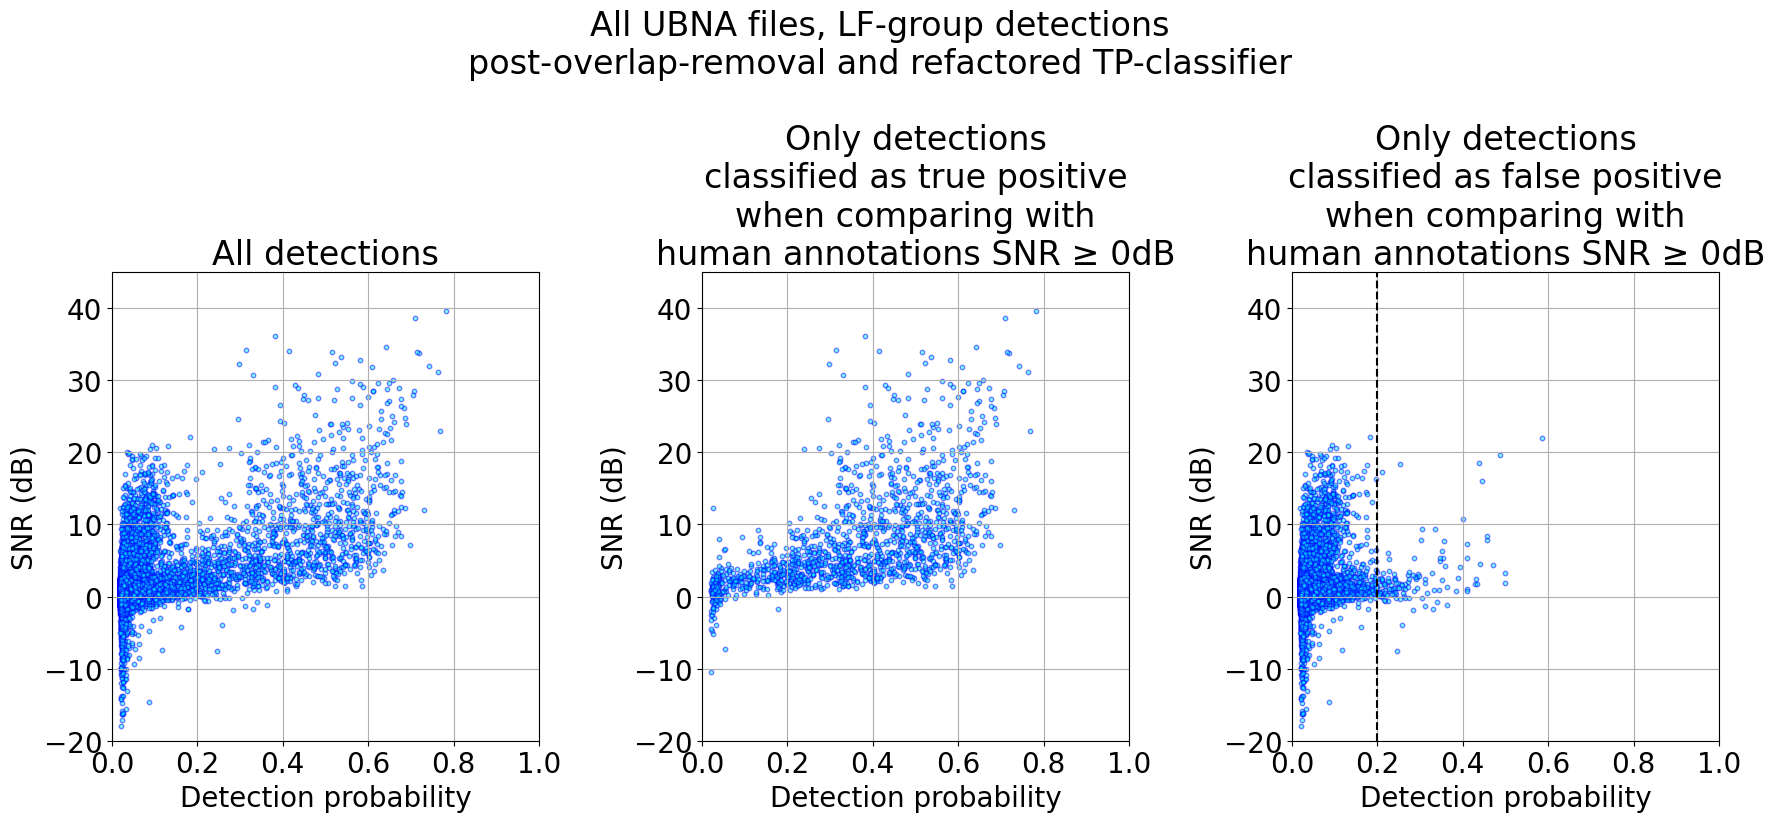

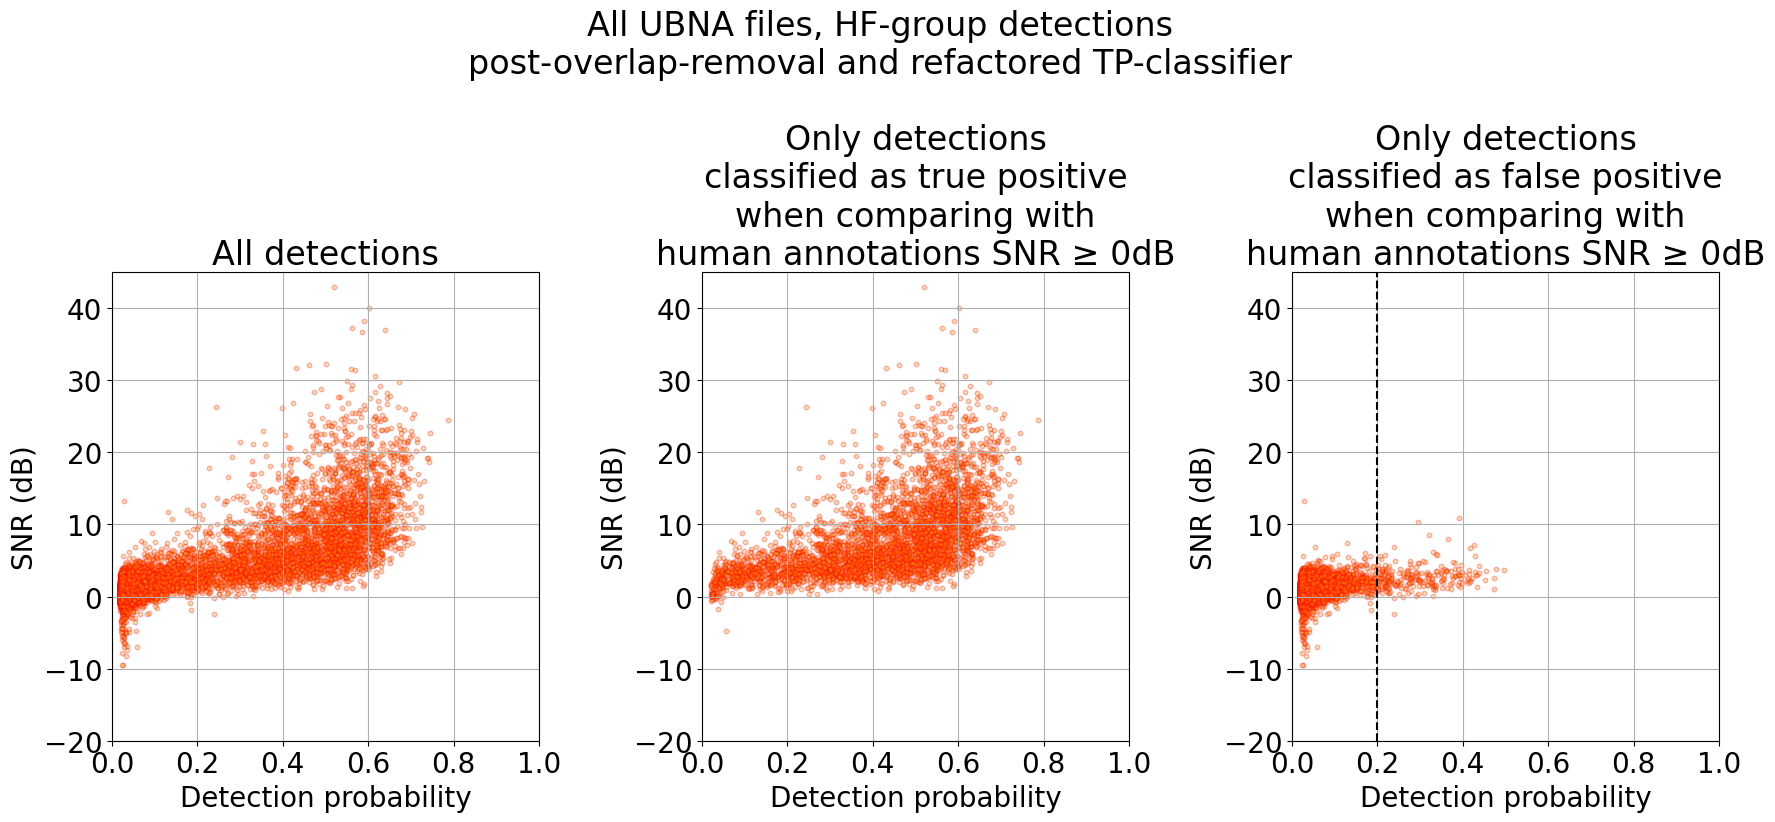

Computing measures for file 20220730_053000.WAV
Human annotations: 787 total, 138 LF, 649 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
135 BD2 true positives
3 BD2 false negatives
21966 BD2 false positives
135 human true positives
HF measures: 
657 BD2 true positives
2 BD2 false negatives
28308 BD2 false positives
647 human true positives
0 LF human annotations each with 2 corresponding true positives
10 HF human annotations each with 2 corresponding true positives
4/15 (0.267) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/36 (0.028) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 4136 total, 1012 LF, 3124 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
990 BD2 true positives
40 BD2 false negatives
28930 BD2 false positives
972 human true positives
HF measures: 
3114 BD2 true positives
34 BD2 

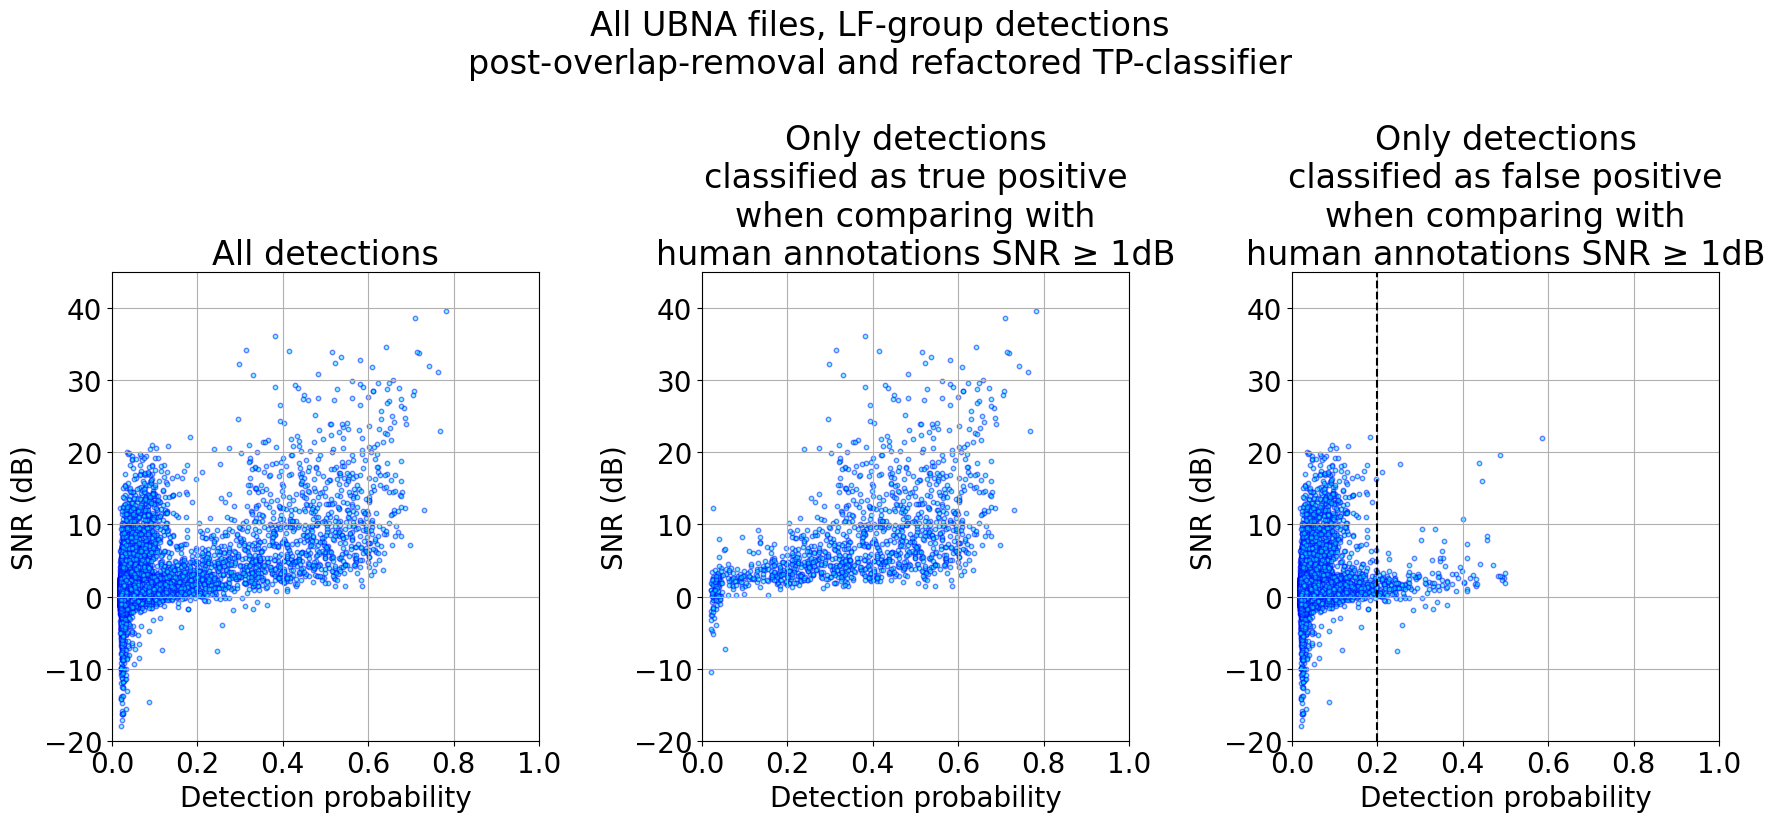

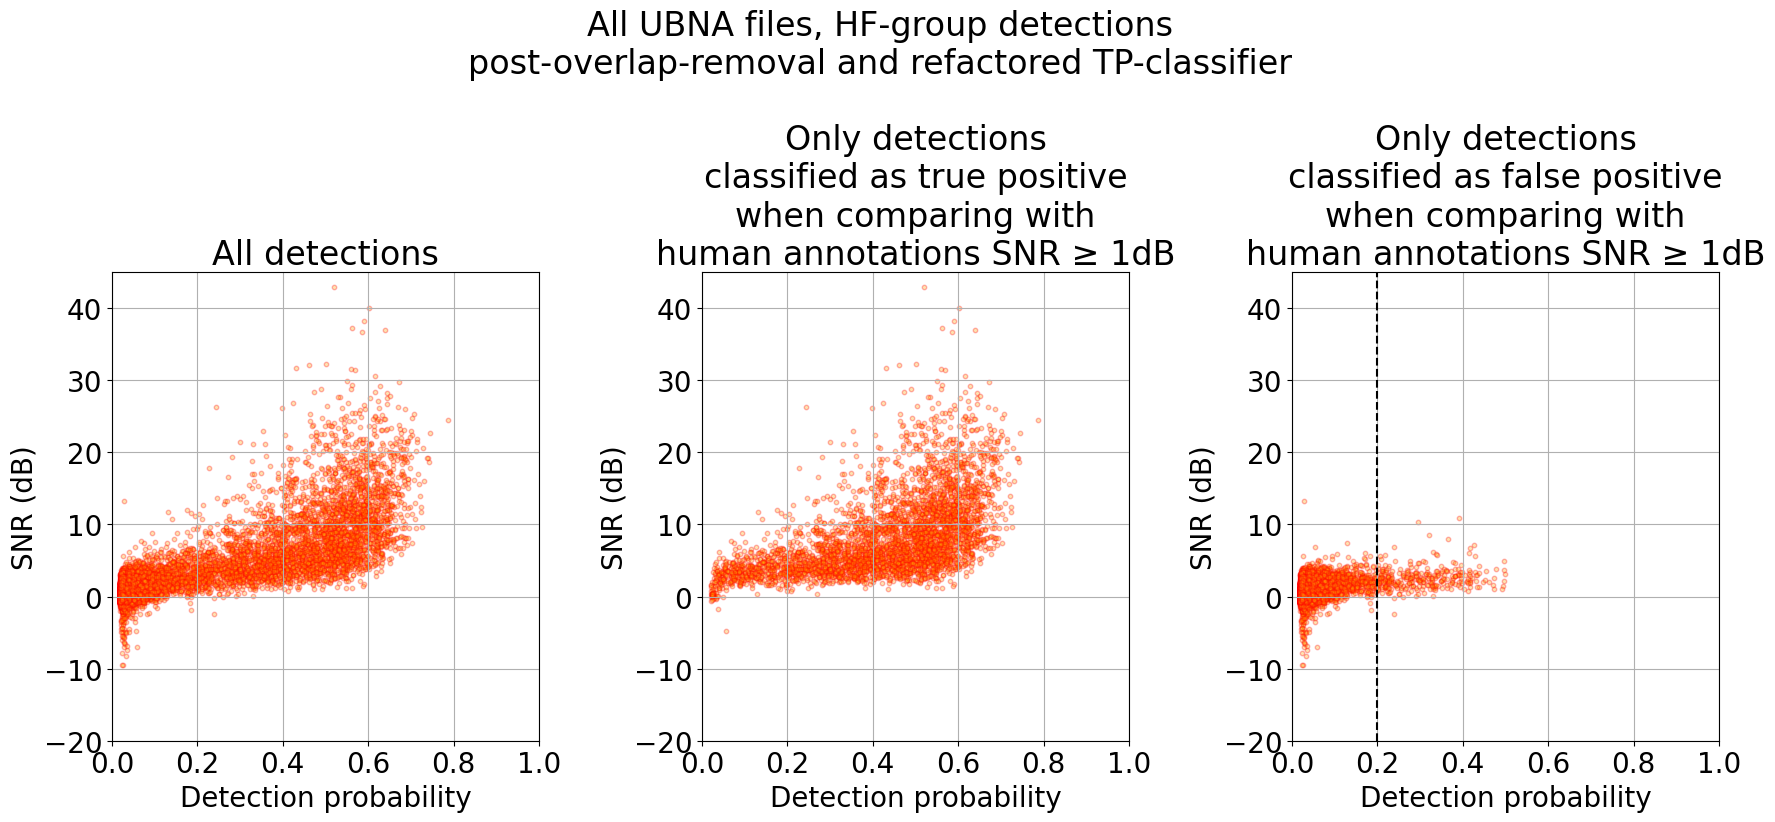

Computing measures for file 20220730_053000.WAV
Human annotations: 681 total, 123 LF, 558 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
120 BD2 true positives
3 BD2 false negatives
21981 BD2 false positives
120 human true positives
HF measures: 
565 BD2 true positives
0 BD2 false negatives
28400 BD2 false positives
558 human true positives
0 LF human annotations each with 2 corresponding true positives
7 HF human annotations each with 2 corresponding true positives
4/22 (0.182) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/88 (0.011) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 3693 total, 859 LF, 2834 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
841 BD2 true positives
31 BD2 false negatives
29079 BD2 false positives
828 human true positives
HF measures: 
2832 BD2 true positives
25 BD2 fa

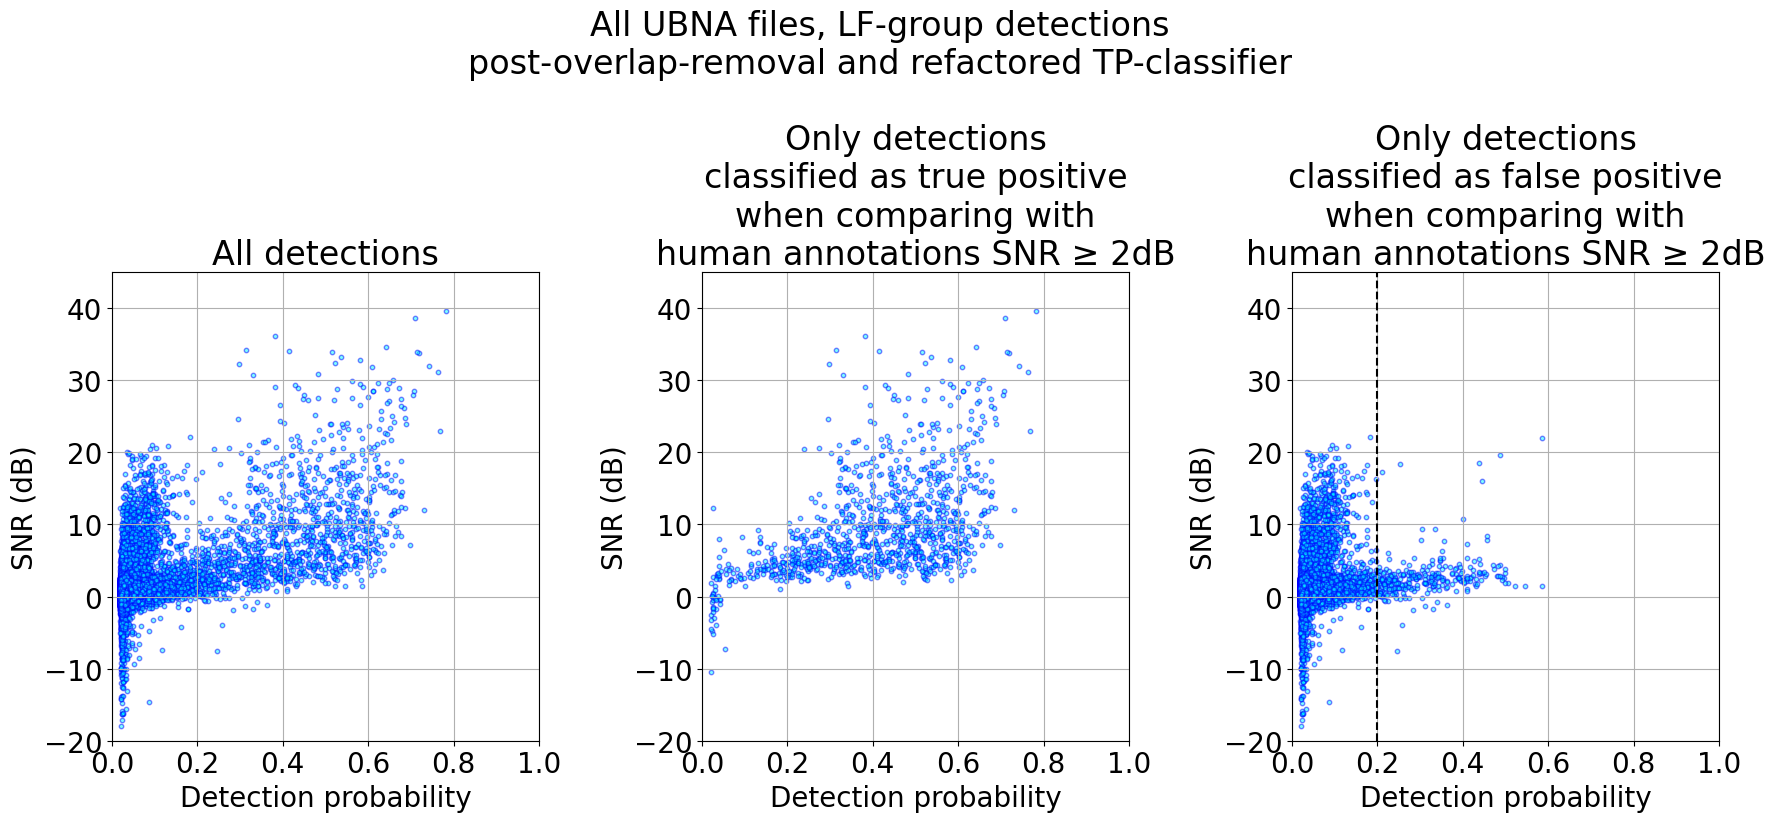

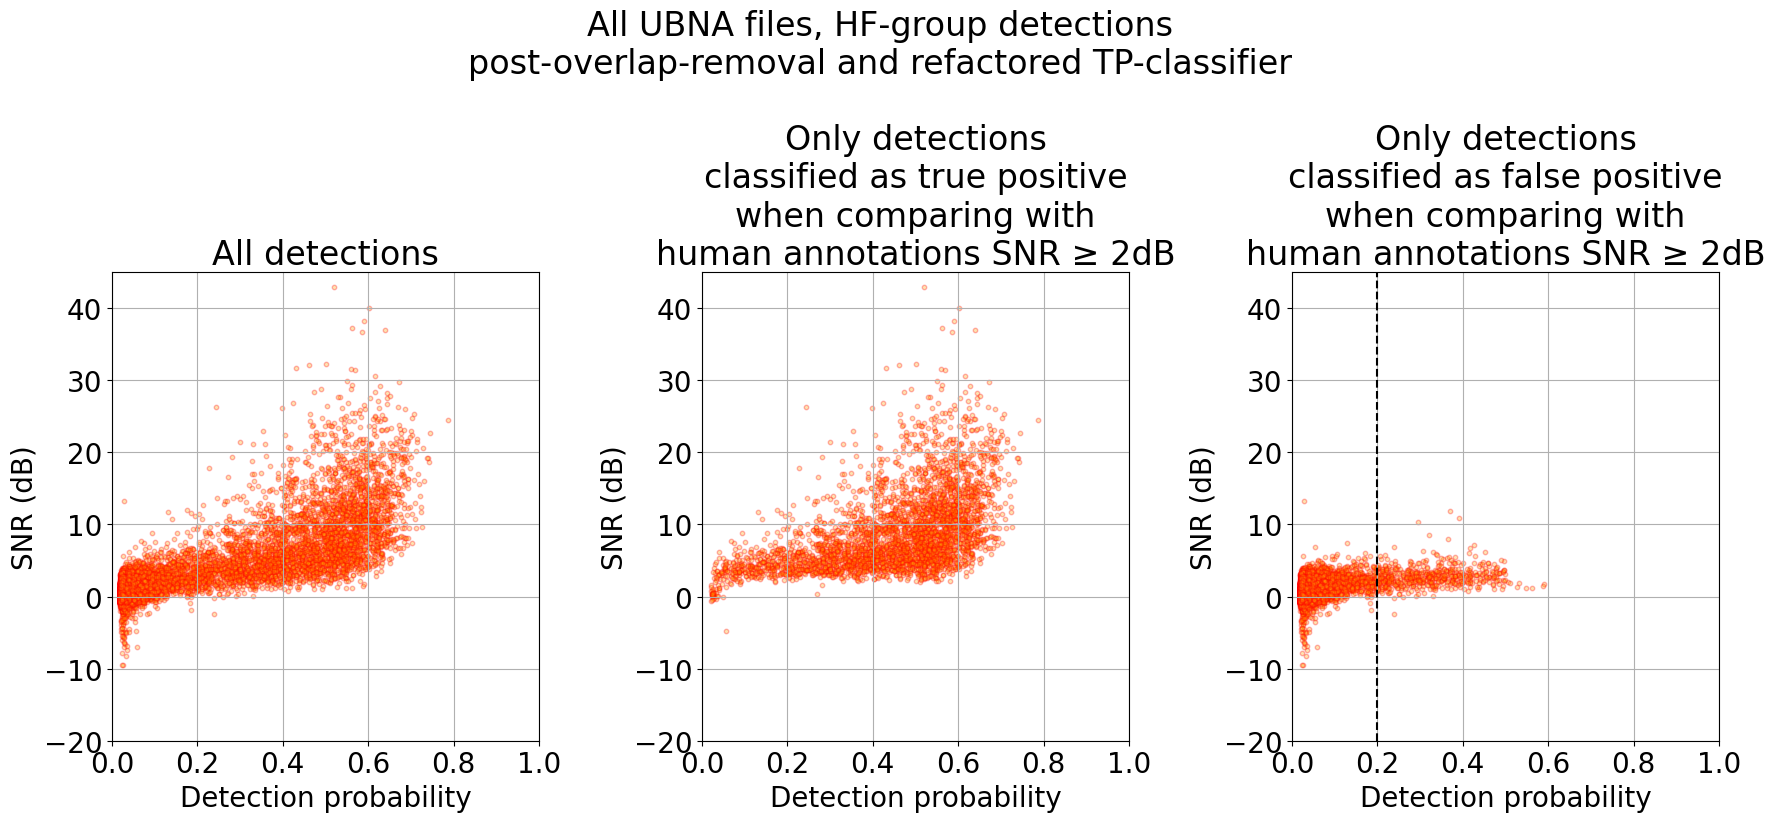

Computing measures for file 20220730_053000.WAV
Human annotations: 595 total, 110 LF, 485 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
107 BD2 true positives
3 BD2 false negatives
21994 BD2 false positives
107 human true positives
HF measures: 
490 BD2 true positives
0 BD2 false negatives
28475 BD2 false positives
485 human true positives
0 LF human annotations each with 2 corresponding true positives
5 HF human annotations each with 2 corresponding true positives
4/32 (0.125) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/141 (0.007) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 3137 total, 715 LF, 2422 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
705 BD2 true positives
20 BD2 false negatives
29215 BD2 false positives
695 human true positives
HF measures: 
2422 BD2 true positives
18 BD2 f

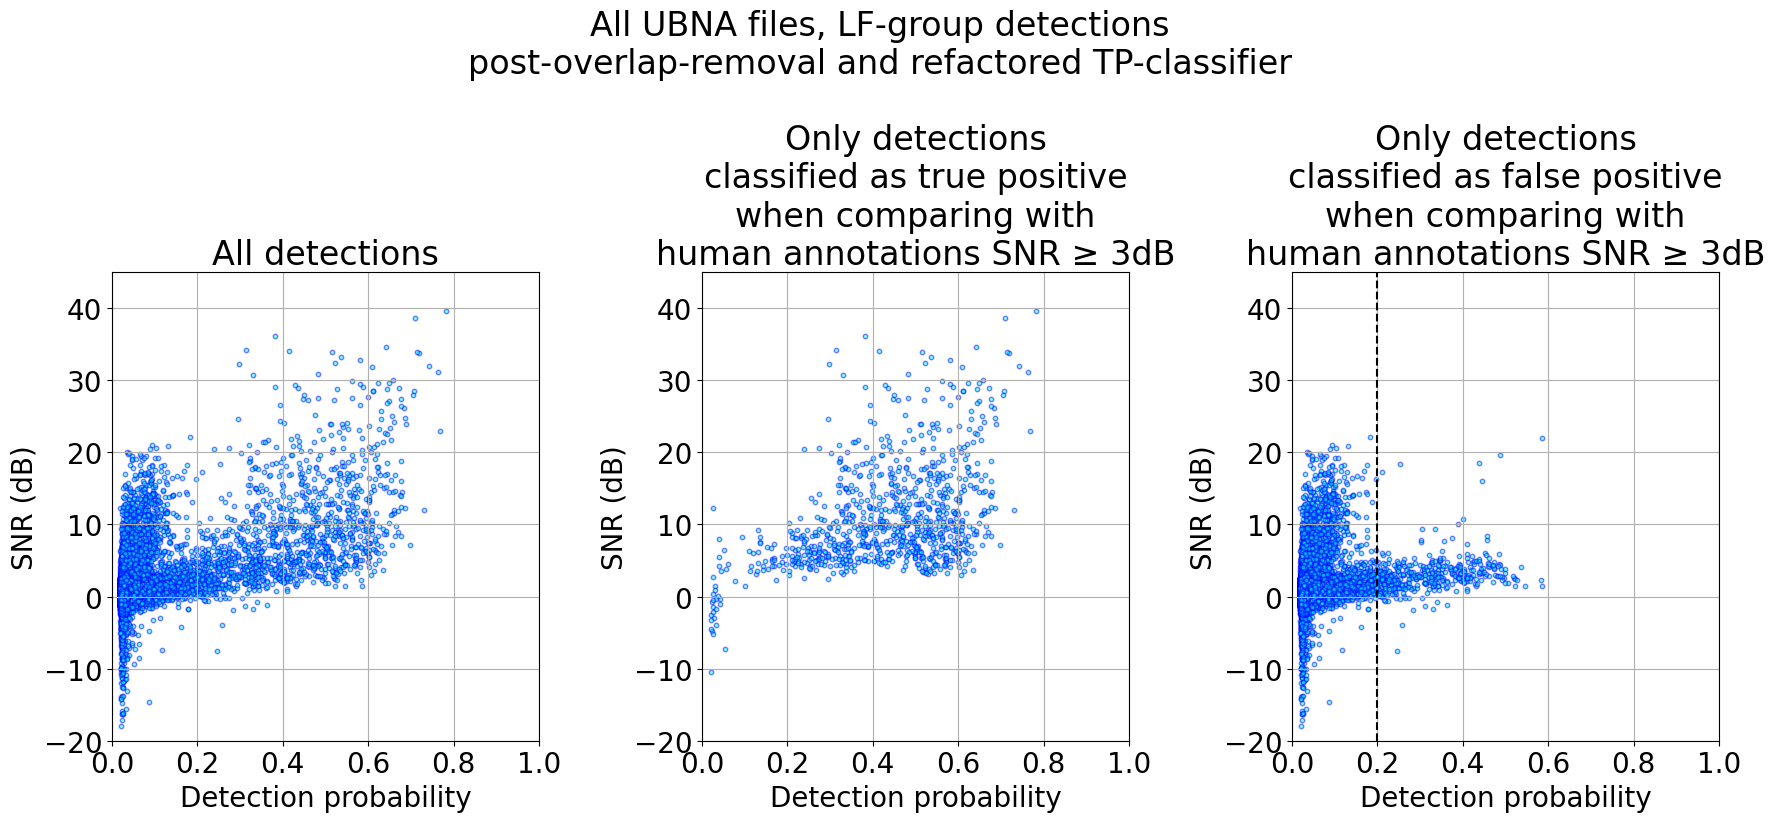

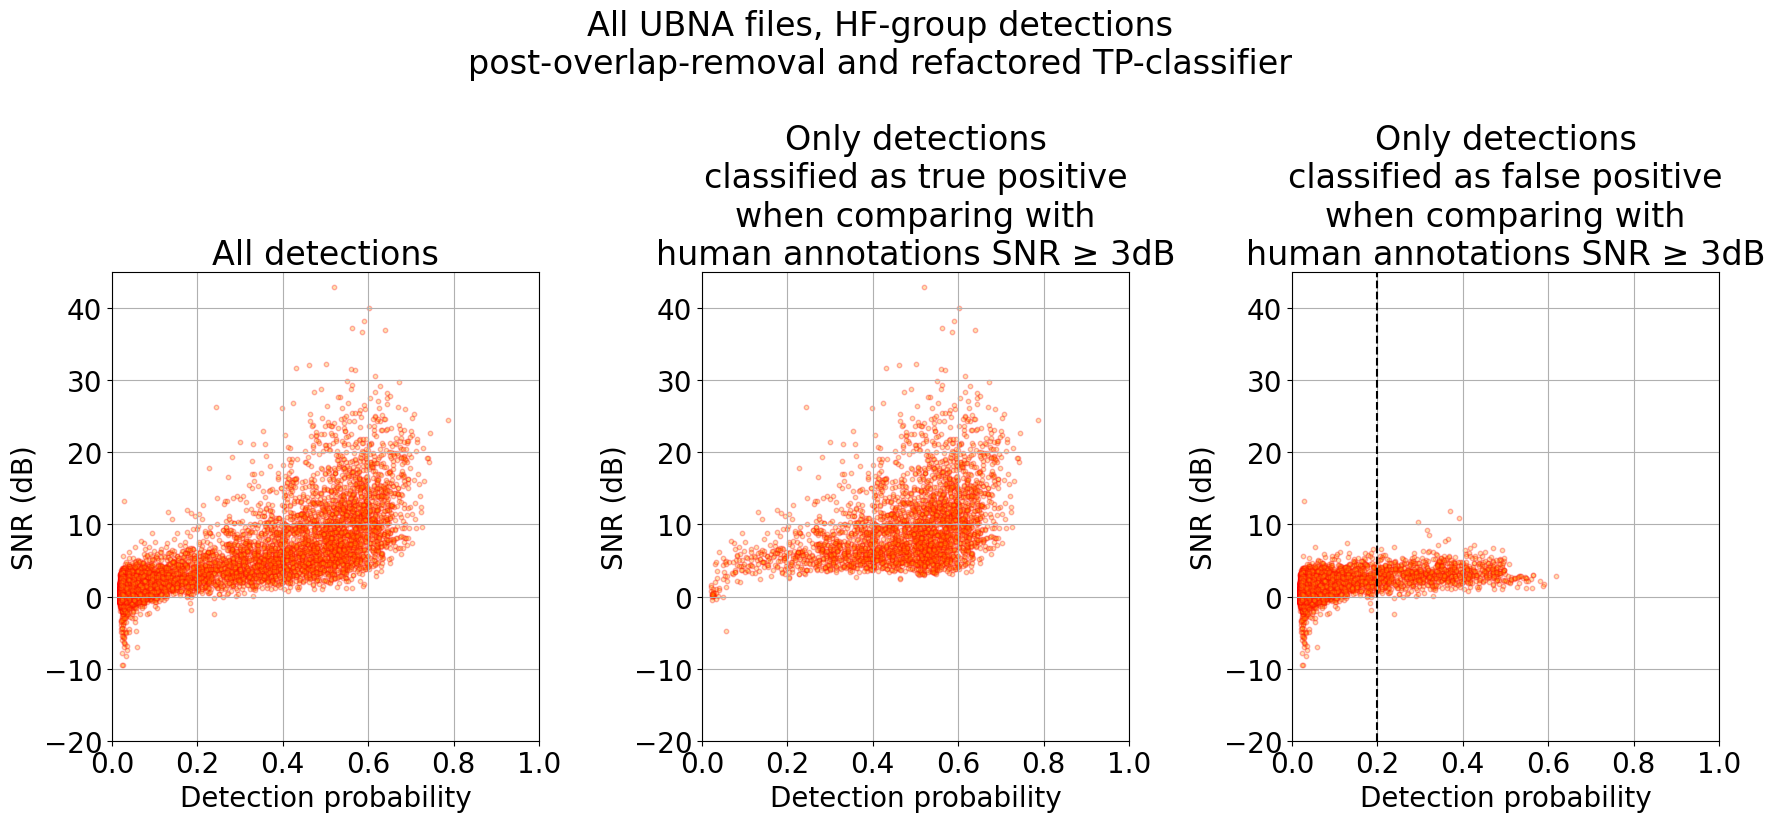

Computing measures for file 20220730_053000.WAV
Human annotations: 528 total, 100 LF, 428 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
97 BD2 true positives
3 BD2 false negatives
22004 BD2 false positives
97 human true positives
HF measures: 
433 BD2 true positives
0 BD2 false negatives
28532 BD2 false positives
428 human true positives
0 LF human annotations each with 2 corresponding true positives
5 HF human annotations each with 2 corresponding true positives
4/40 (0.1) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/193 (0.005) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 2670 total, 591 LF, 2079 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
590 BD2 true positives
11 BD2 false negatives
29330 BD2 false positives
580 human true positives
HF measures: 
2083 BD2 true positives
13 BD2 false

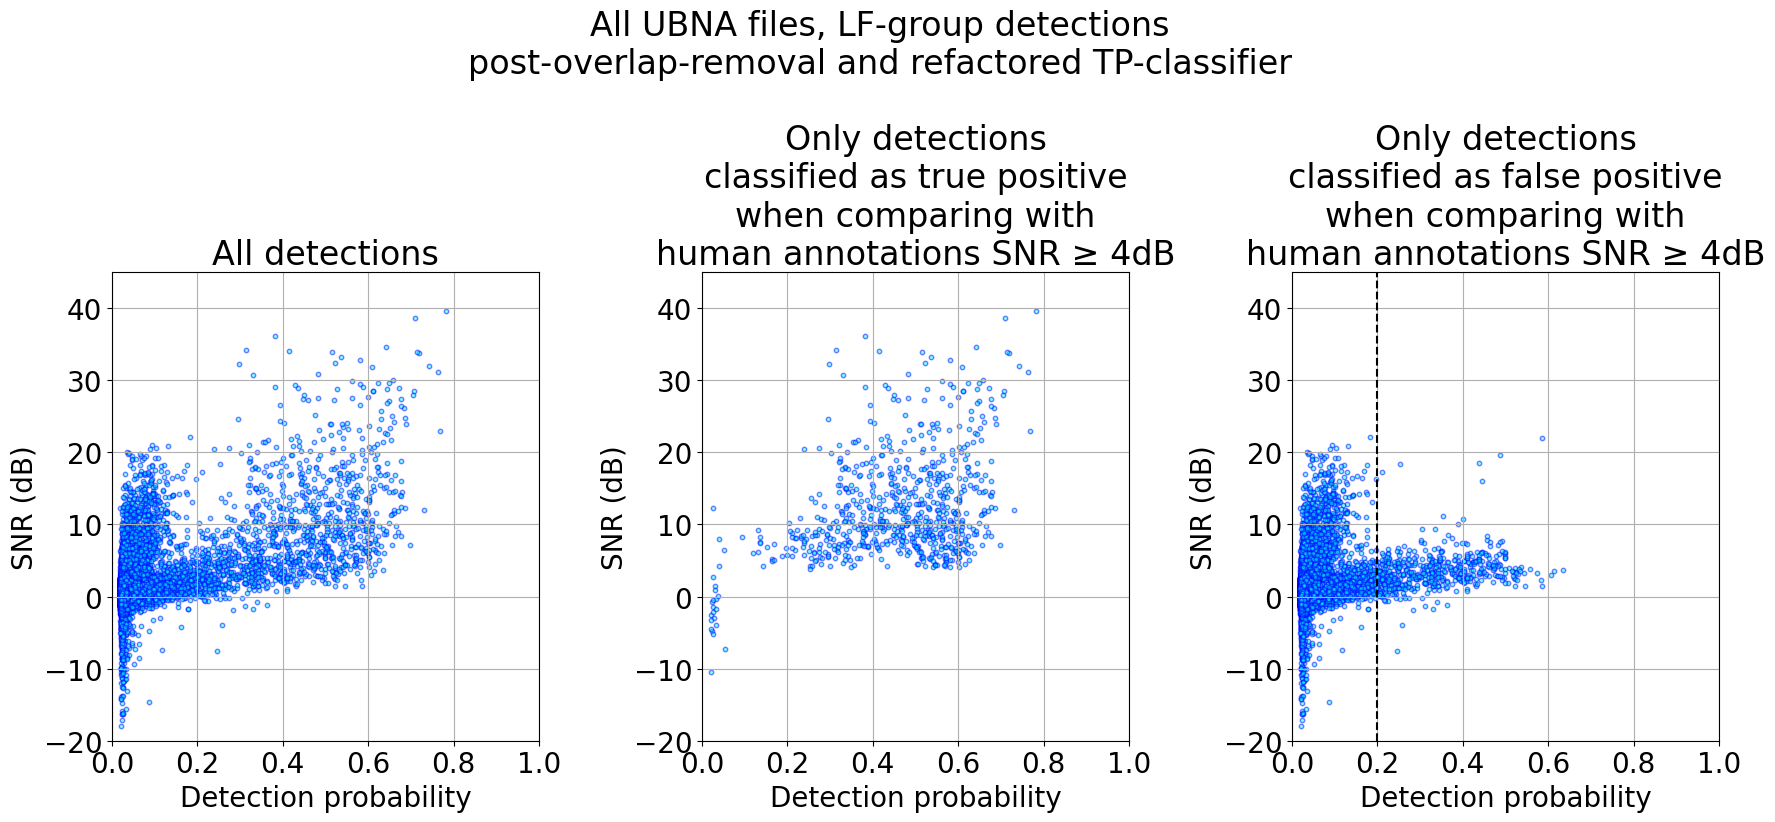

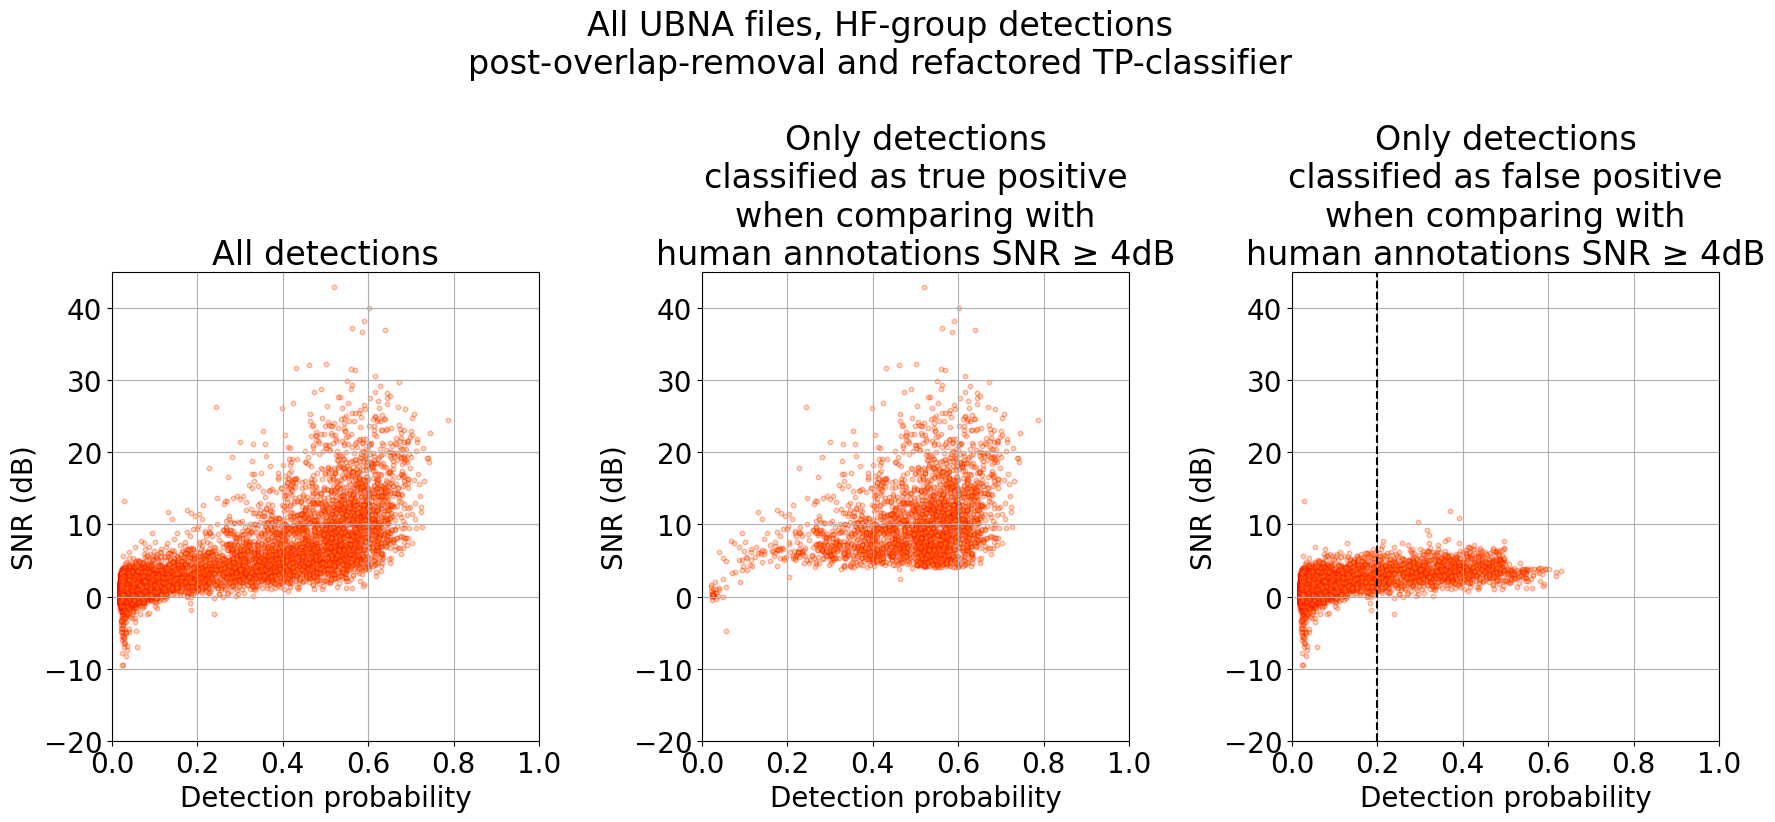

Computing measures for file 20220730_053000.WAV
Human annotations: 465 total, 94 LF, 371 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
91 BD2 true positives
3 BD2 false negatives
22010 BD2 false positives
91 human true positives
HF measures: 
376 BD2 true positives
0 BD2 false negatives
28589 BD2 false positives
371 human true positives
0 LF human annotations each with 2 corresponding true positives
5 HF human annotations each with 2 corresponding true positives
4/44 (0.091) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/248 (0.004) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 2296 total, 511 LF, 1785 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
513 BD2 true positives
8 BD2 false negatives
29407 BD2 false positives
503 human true positives
HF measures: 
1786 BD2 true positives
11 BD2 false

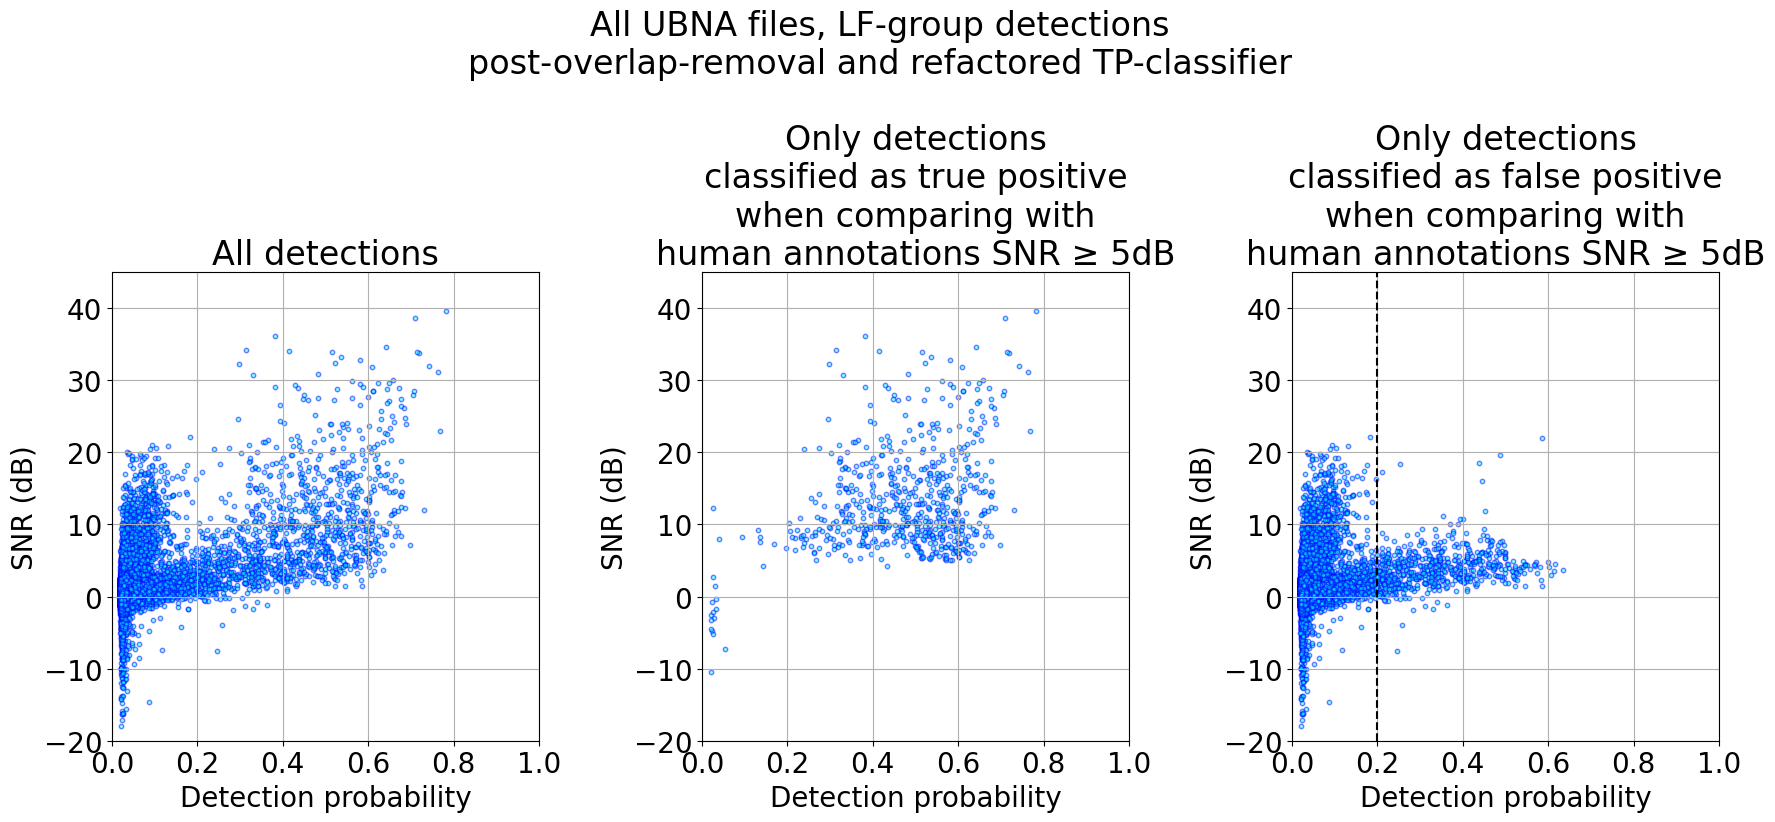

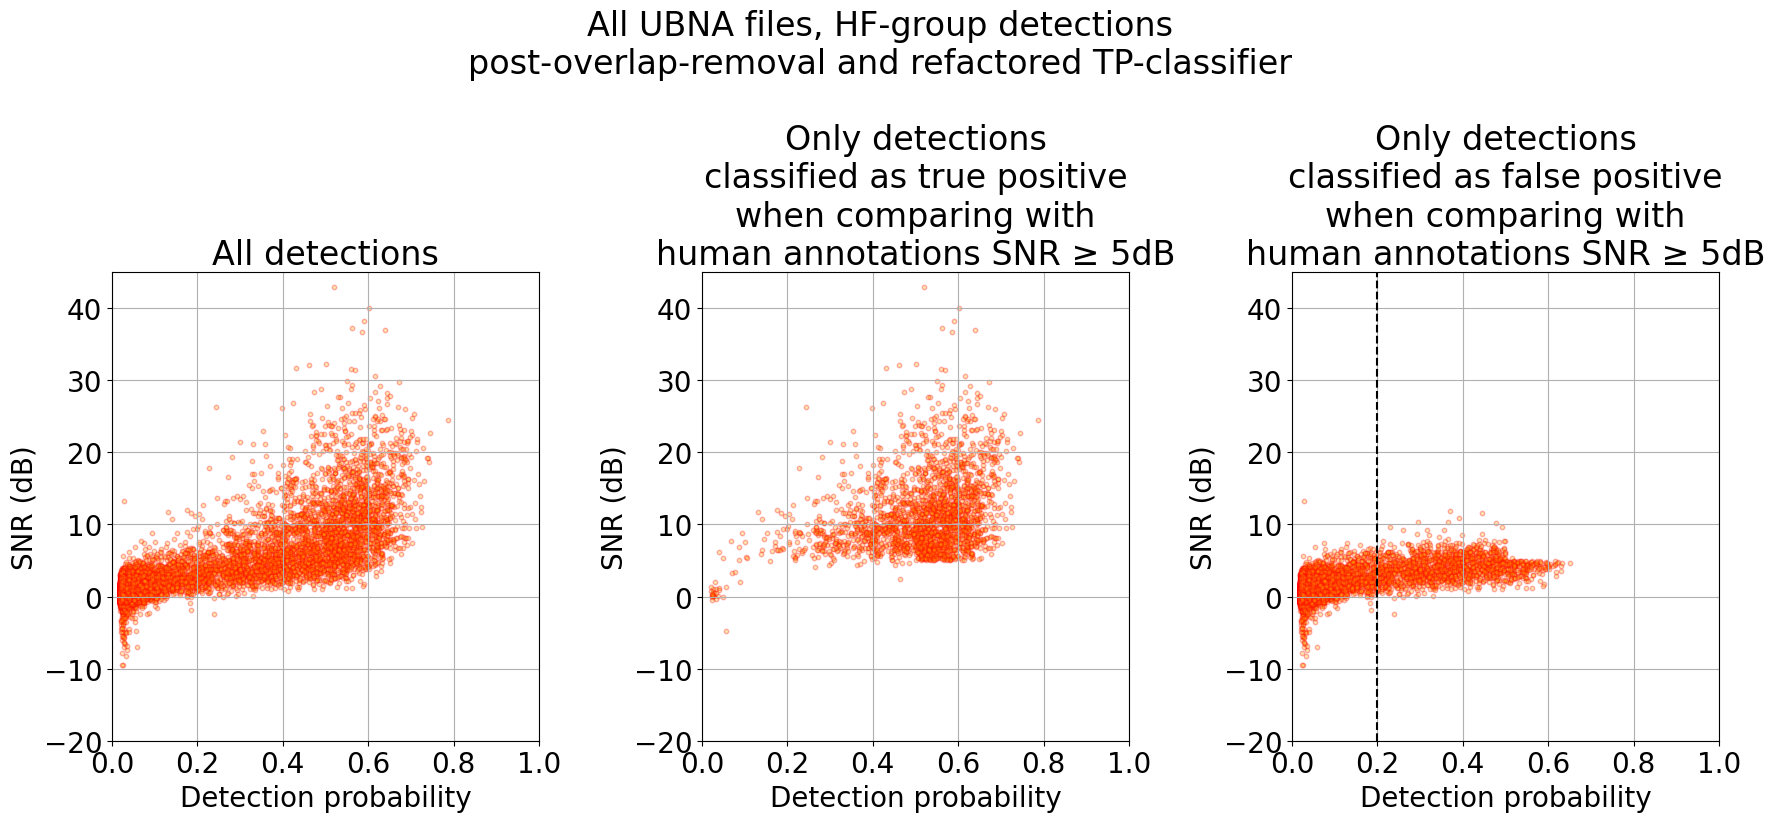

Computing measures for file 20220730_053000.WAV
Human annotations: 399 total, 85 LF, 314 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
82 BD2 true positives
3 BD2 false negatives
22019 BD2 false positives
82 human true positives
HF measures: 
316 BD2 true positives
0 BD2 false negatives
28649 BD2 false positives
314 human true positives
0 LF human annotations each with 2 corresponding true positives
2 HF human annotations each with 2 corresponding true positives
4/52 (0.077) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
2/304 (0.007) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 1994 total, 455 LF, 1539 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
459 BD2 true positives
5 BD2 false negatives
29461 BD2 false positives
450 human true positives
HF measures: 
1545 BD2 true positives
6 BD2 false 

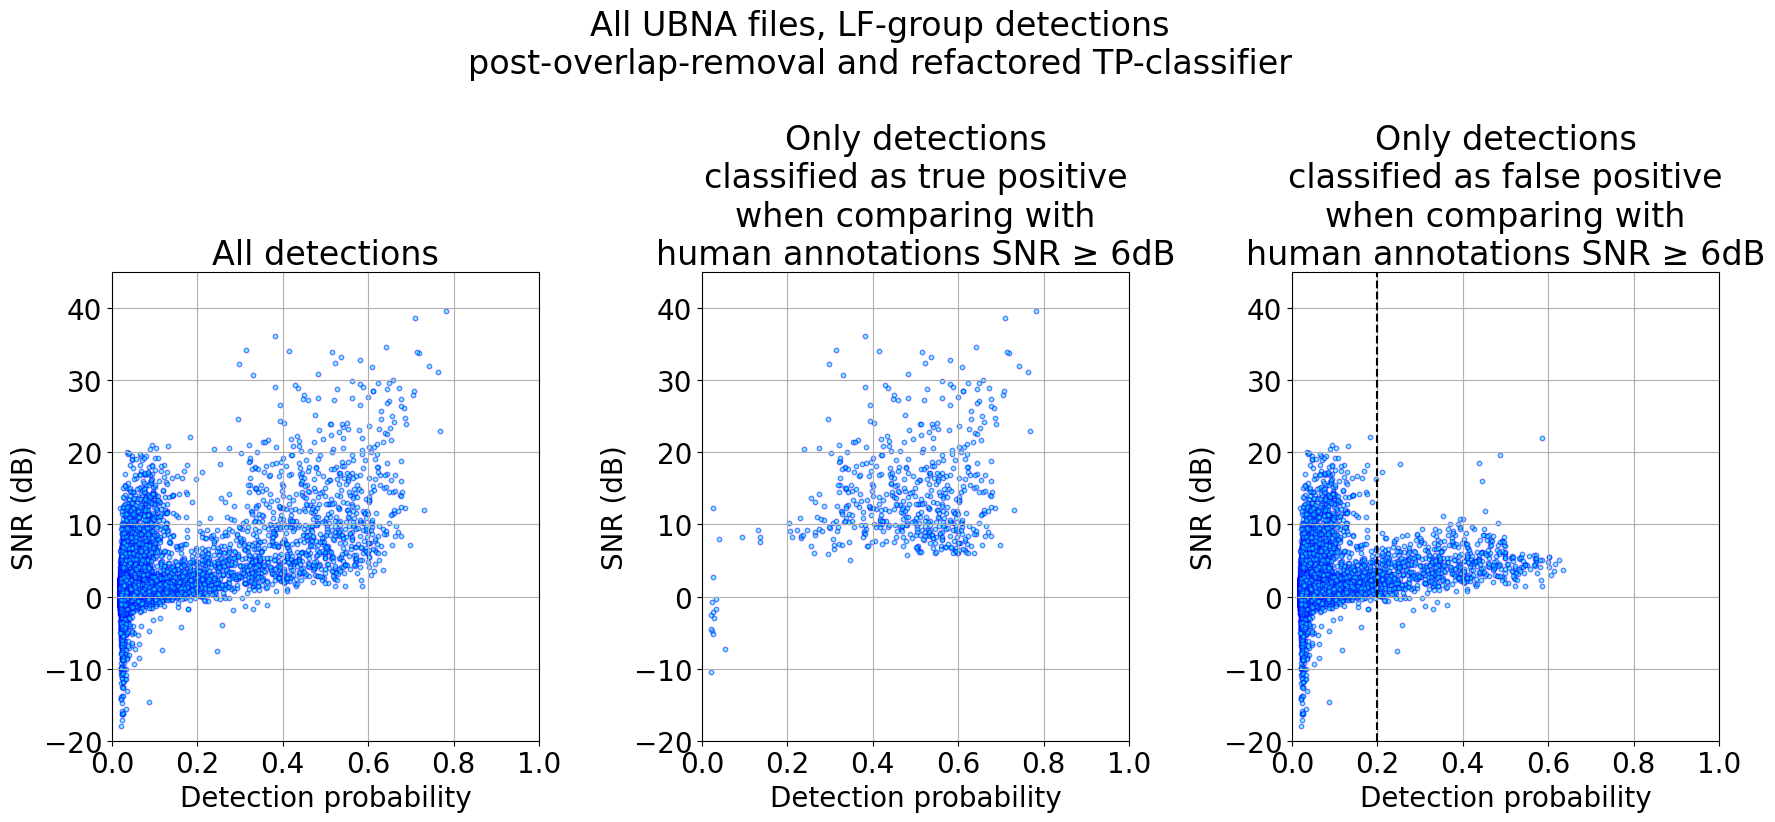

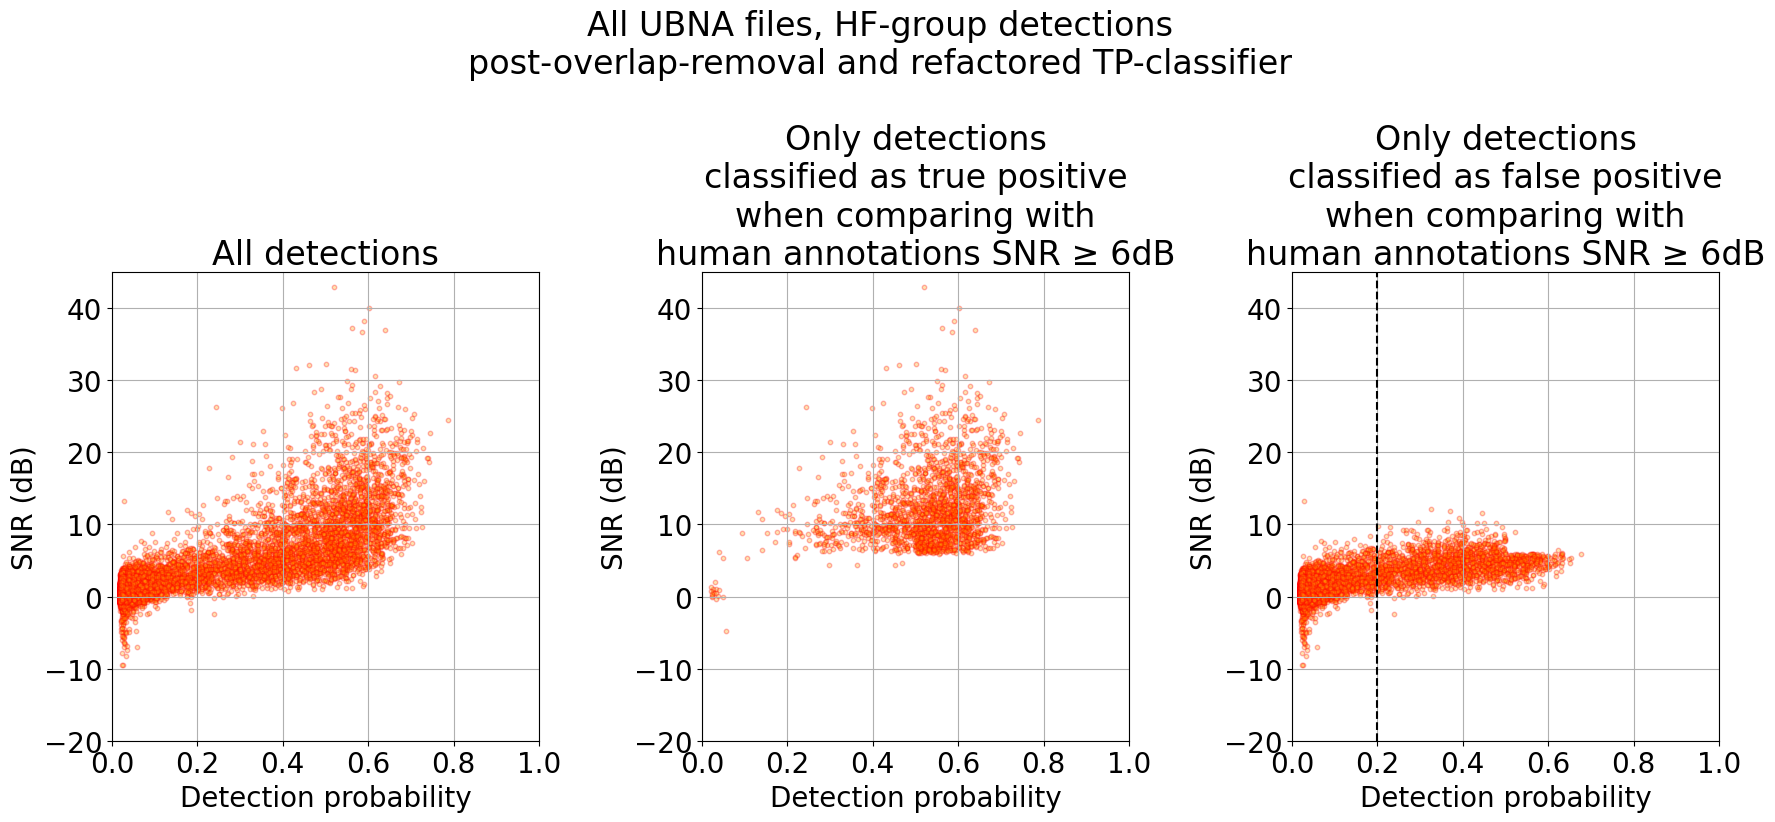

Computing measures for file 20220730_053000.WAV
Human annotations: 332 total, 73 LF, 259 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
71 BD2 true positives
2 BD2 false negatives
22030 BD2 false positives
71 human true positives
HF measures: 
261 BD2 true positives
0 BD2 false negatives
28704 BD2 false positives
259 human true positives
0 LF human annotations each with 2 corresponding true positives
2 HF human annotations each with 2 corresponding true positives
3/63 (0.048) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
2/359 (0.006) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 1760 total, 405 LF, 1355 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
408 BD2 true positives
5 BD2 false negatives
29512 BD2 false positives
400 human true positives
HF measures: 
1361 BD2 true positives
5 BD2 false 

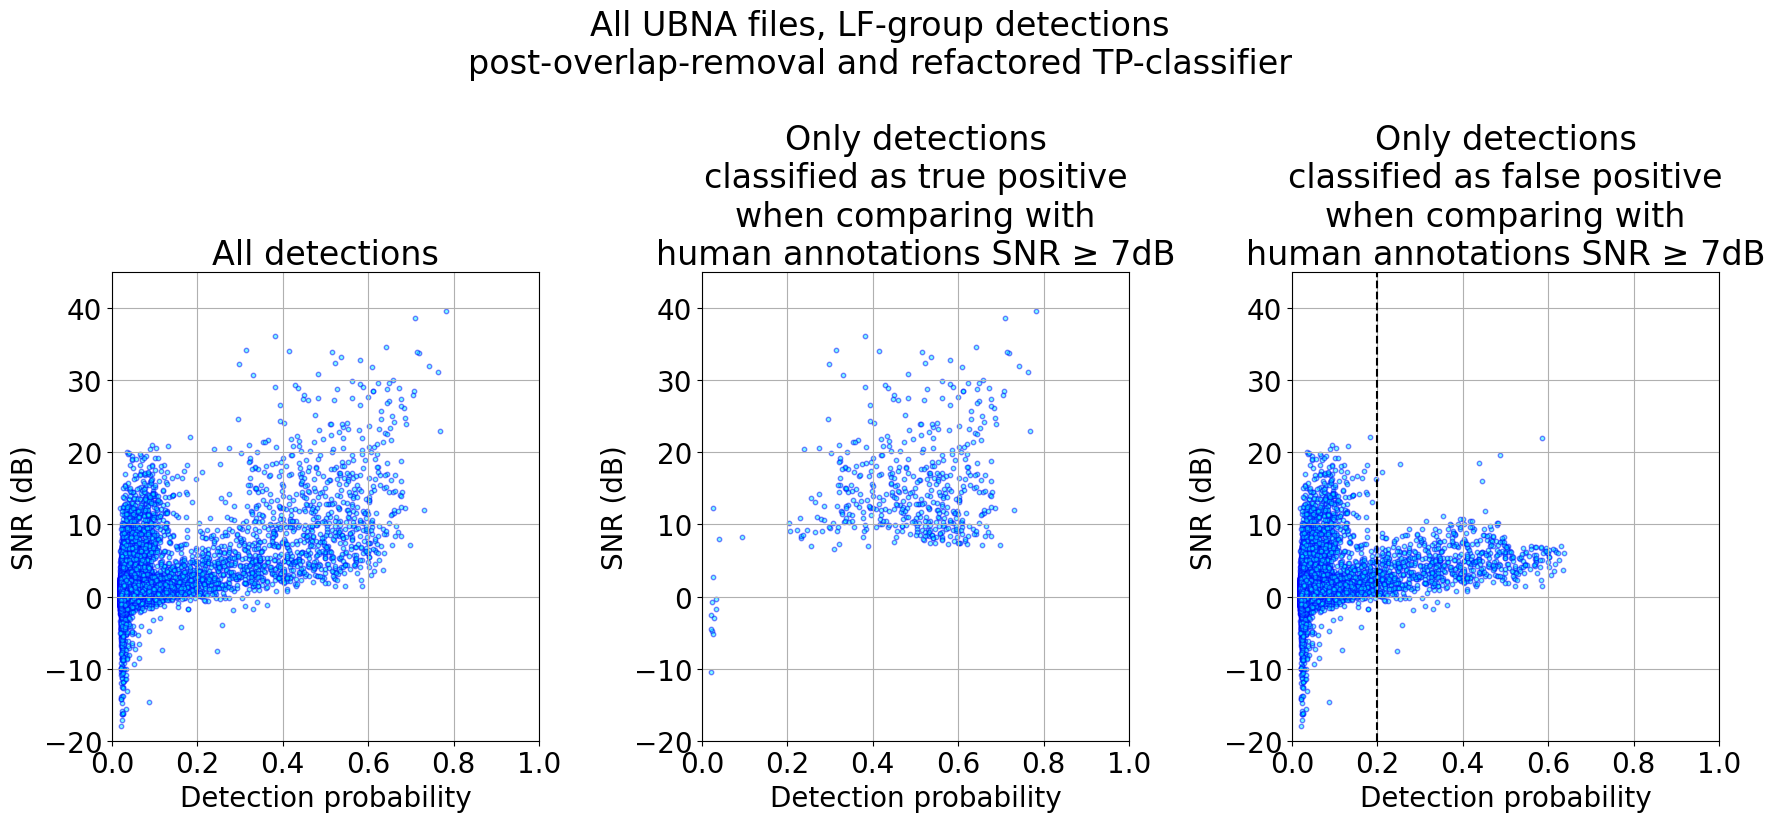

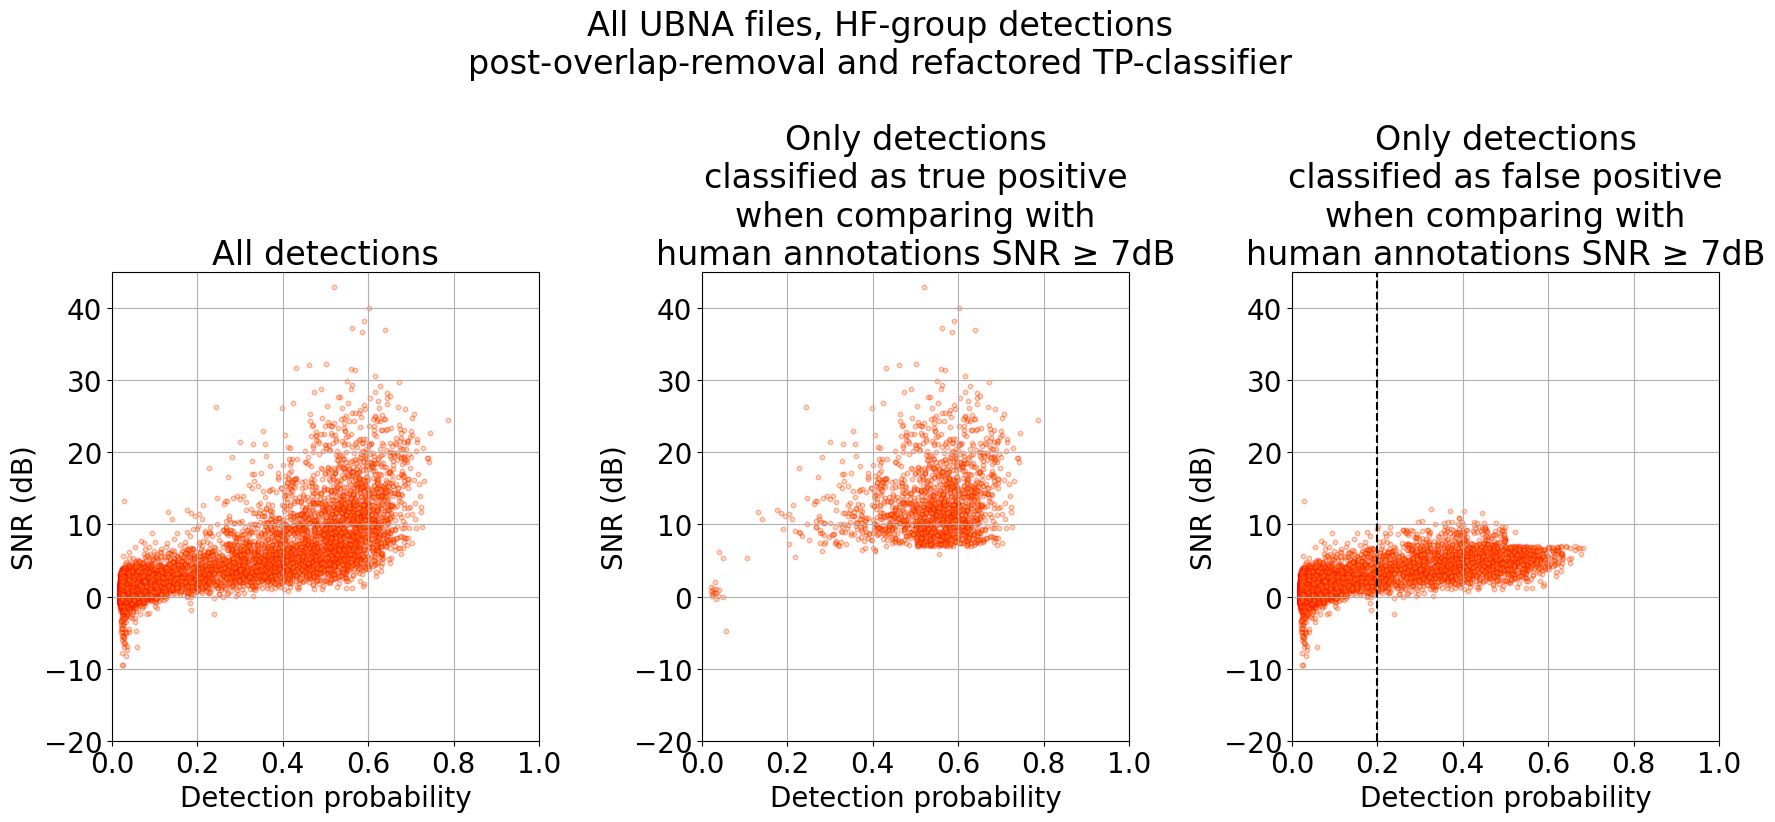

Computing measures for file 20220730_053000.WAV
Human annotations: 281 total, 65 LF, 216 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
63 BD2 true positives
2 BD2 false negatives
22038 BD2 false positives
63 human true positives
HF measures: 
217 BD2 true positives
0 BD2 false negatives
28748 BD2 false positives
216 human true positives
0 LF human annotations each with 2 corresponding true positives
1 HF human annotations each with 2 corresponding true positives
2/70 (0.029) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
2/401 (0.005) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 1528 total, 357 LF, 1171 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
358 BD2 true positives
5 BD2 false negatives
29562 BD2 false positives
352 human true positives
HF measures: 
1174 BD2 true positives
4 BD2 false 

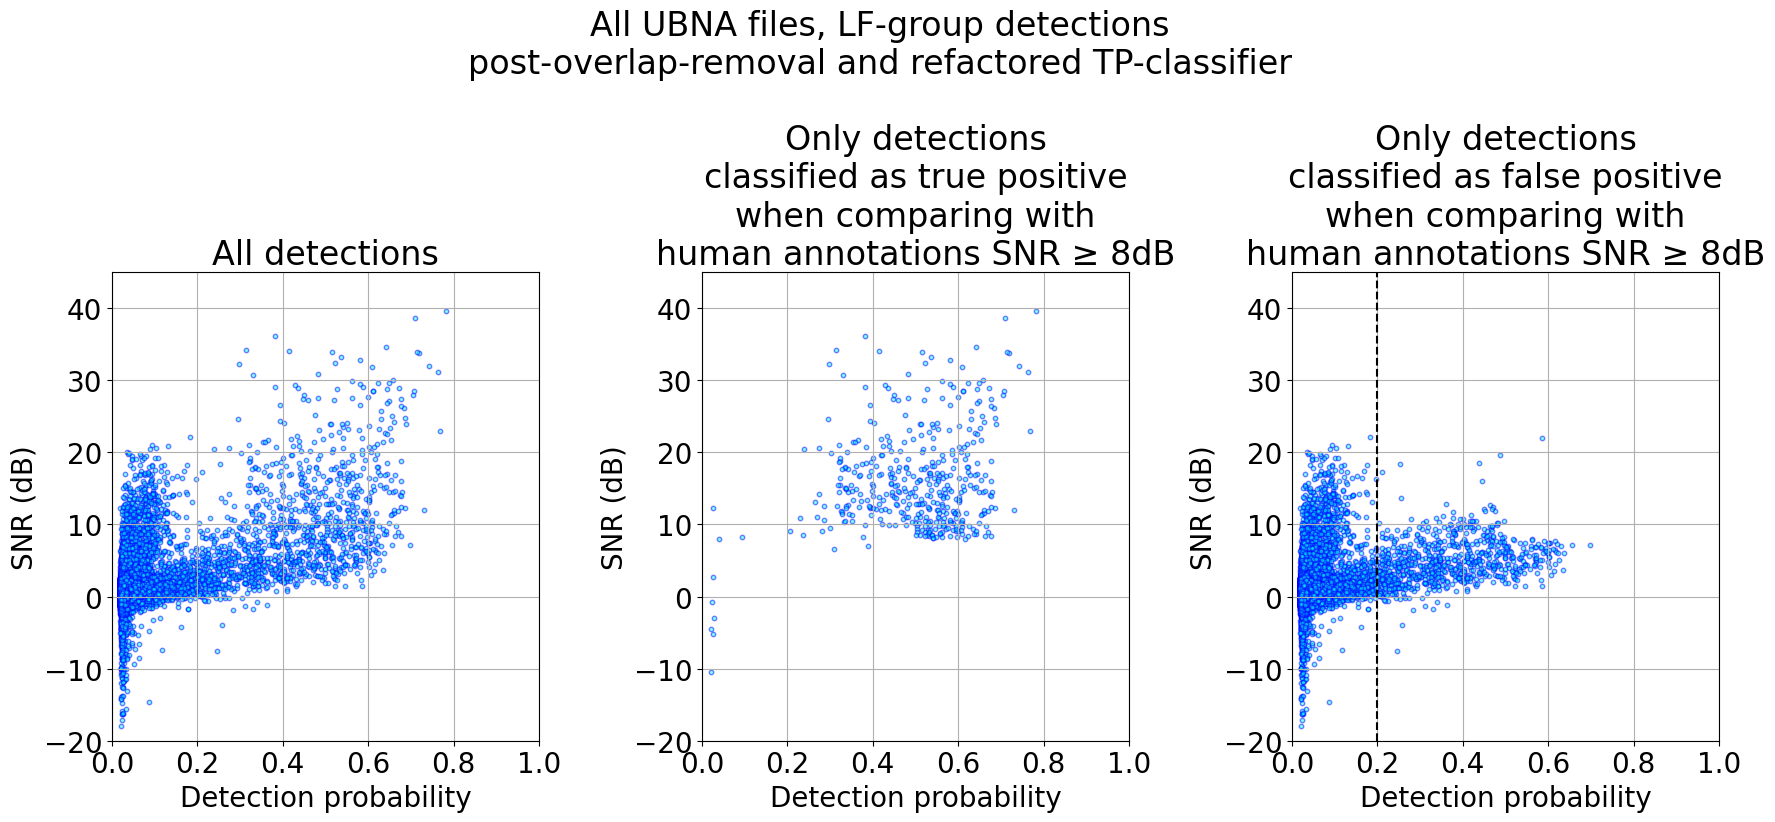

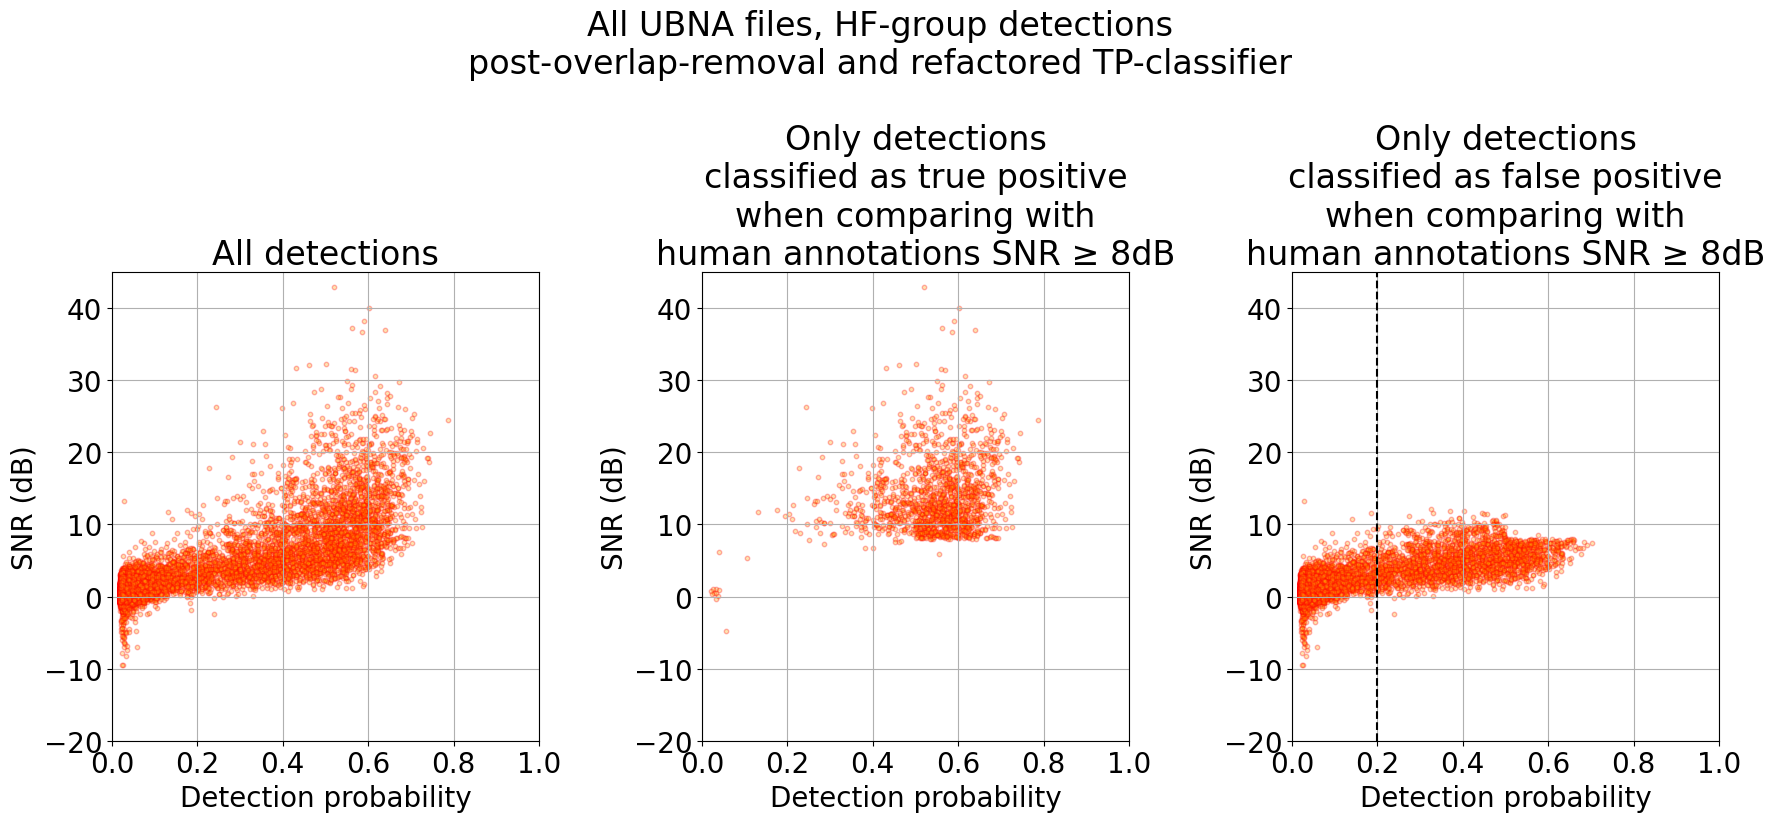

Computing measures for file 20220730_053000.WAV
Human annotations: 240 total, 62 LF, 178 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
60 BD2 true positives
2 BD2 false negatives
22041 BD2 false positives
60 human true positives
HF measures: 
179 BD2 true positives
0 BD2 false negatives
28786 BD2 false positives
178 human true positives
0 LF human annotations each with 2 corresponding true positives
1 HF human annotations each with 2 corresponding true positives
2/73 (0.027) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
1/439 (0.002) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 1321 total, 309 LF, 1012 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
311 BD2 true positives
3 BD2 false negatives
29609 BD2 false positives
306 human true positives
HF measures: 
1015 BD2 true positives
3 BD2 false 

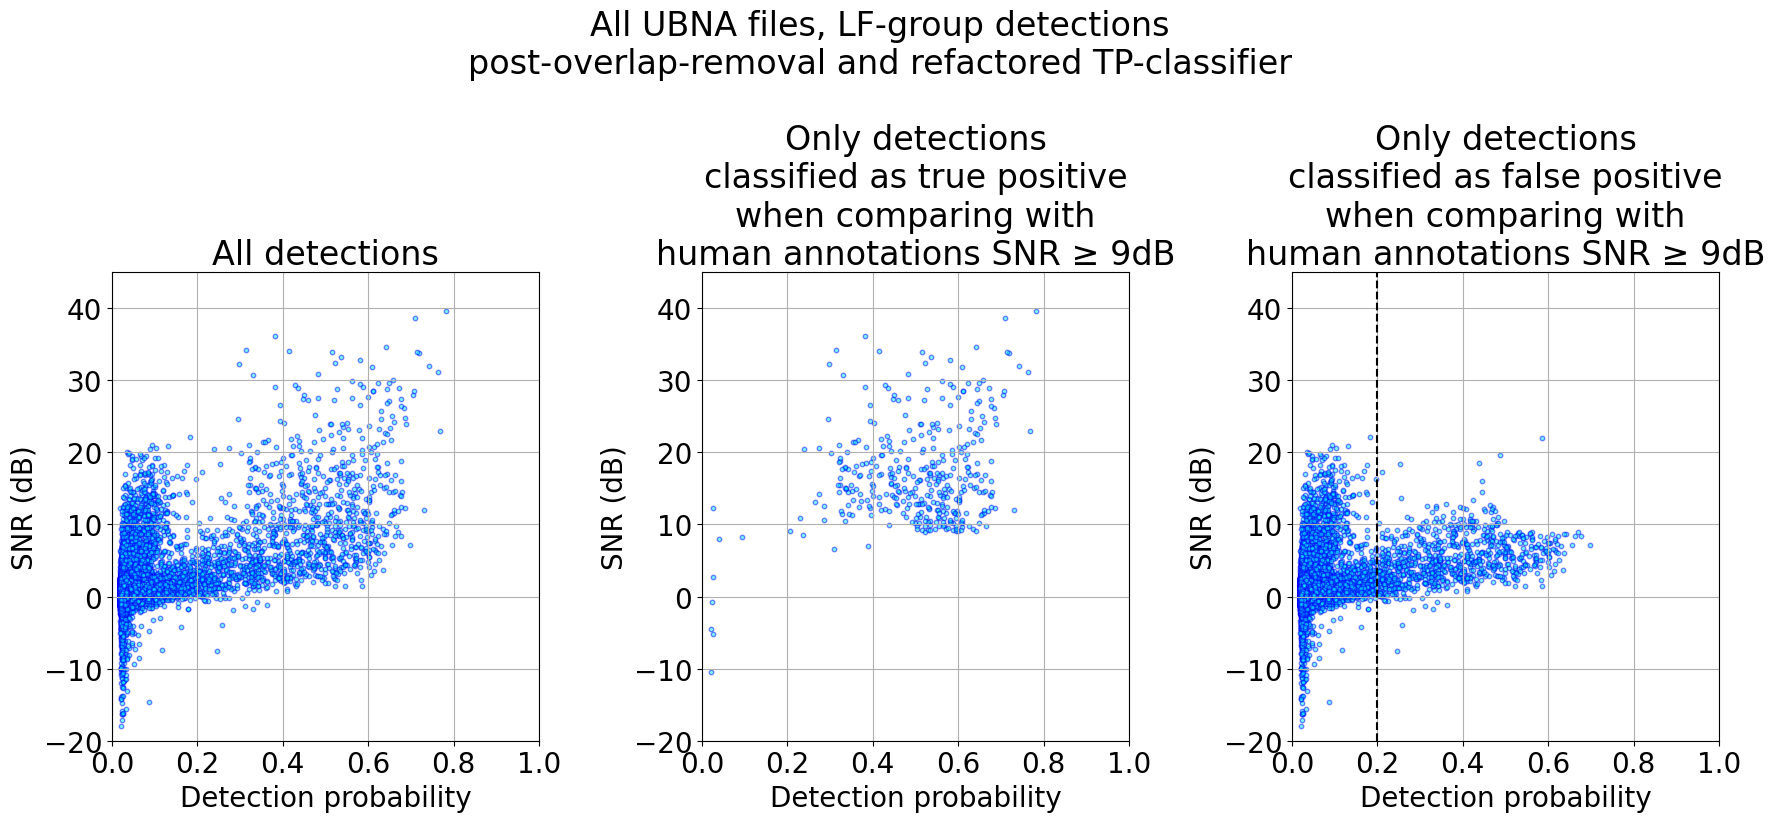

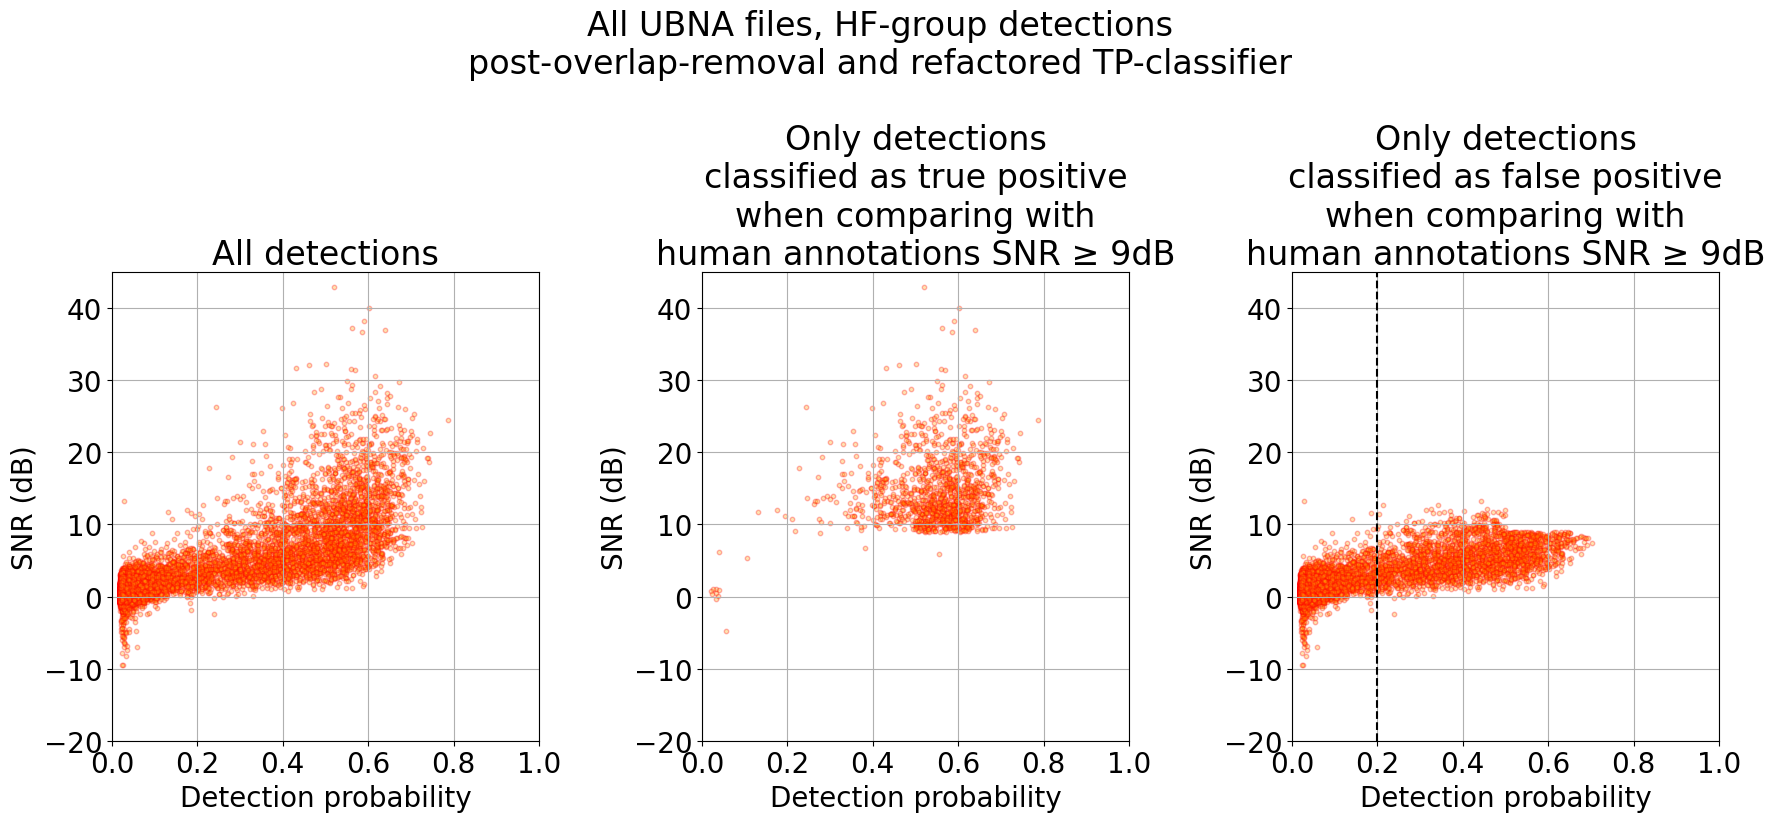

Computing measures for file 20220730_053000.WAV
Human annotations: 205 total, 55 LF, 150 HF
BD2 detections: 51066 total, 22101 LF, 28965 HF
LF measures: 
53 BD2 true positives
2 BD2 false negatives
22048 BD2 false positives
53 human true positives
HF measures: 
151 BD2 true positives
0 BD2 false negatives
28814 BD2 false positives
150 human true positives
0 LF human annotations each with 2 corresponding true positives
1 HF human annotations each with 2 corresponding true positives
2/80 (0.025) LF false positives were actually true positives with peak times distances > 12ms but < 32ms
0/467 (0.0) HF false positives were actually true positives with peak times distances > 12ms but < 20ms
Computing measures for file 20220826_070000.WAV
Human annotations: 1149 total, 266 LF, 883 HF
BD2 detections: 52825 total, 29920 LF, 22905 HF
LF measures: 
268 BD2 true positives
3 BD2 false negatives
29652 BD2 false positives
263 human true positives
HF measures: 
885 BD2 true positives
1 BD2 false nega

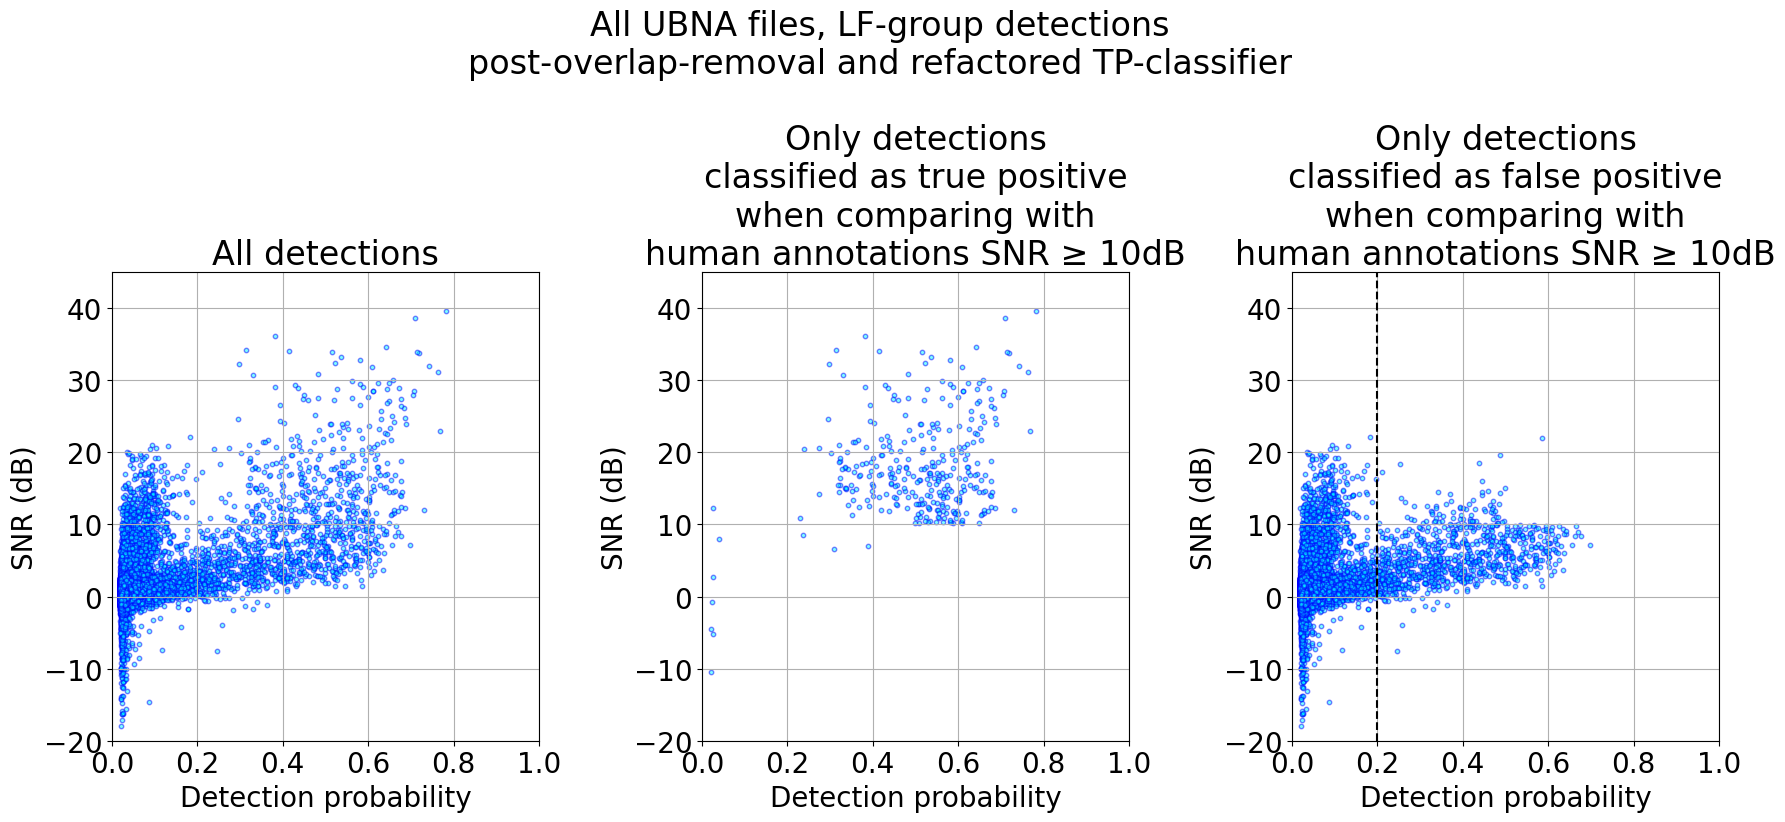

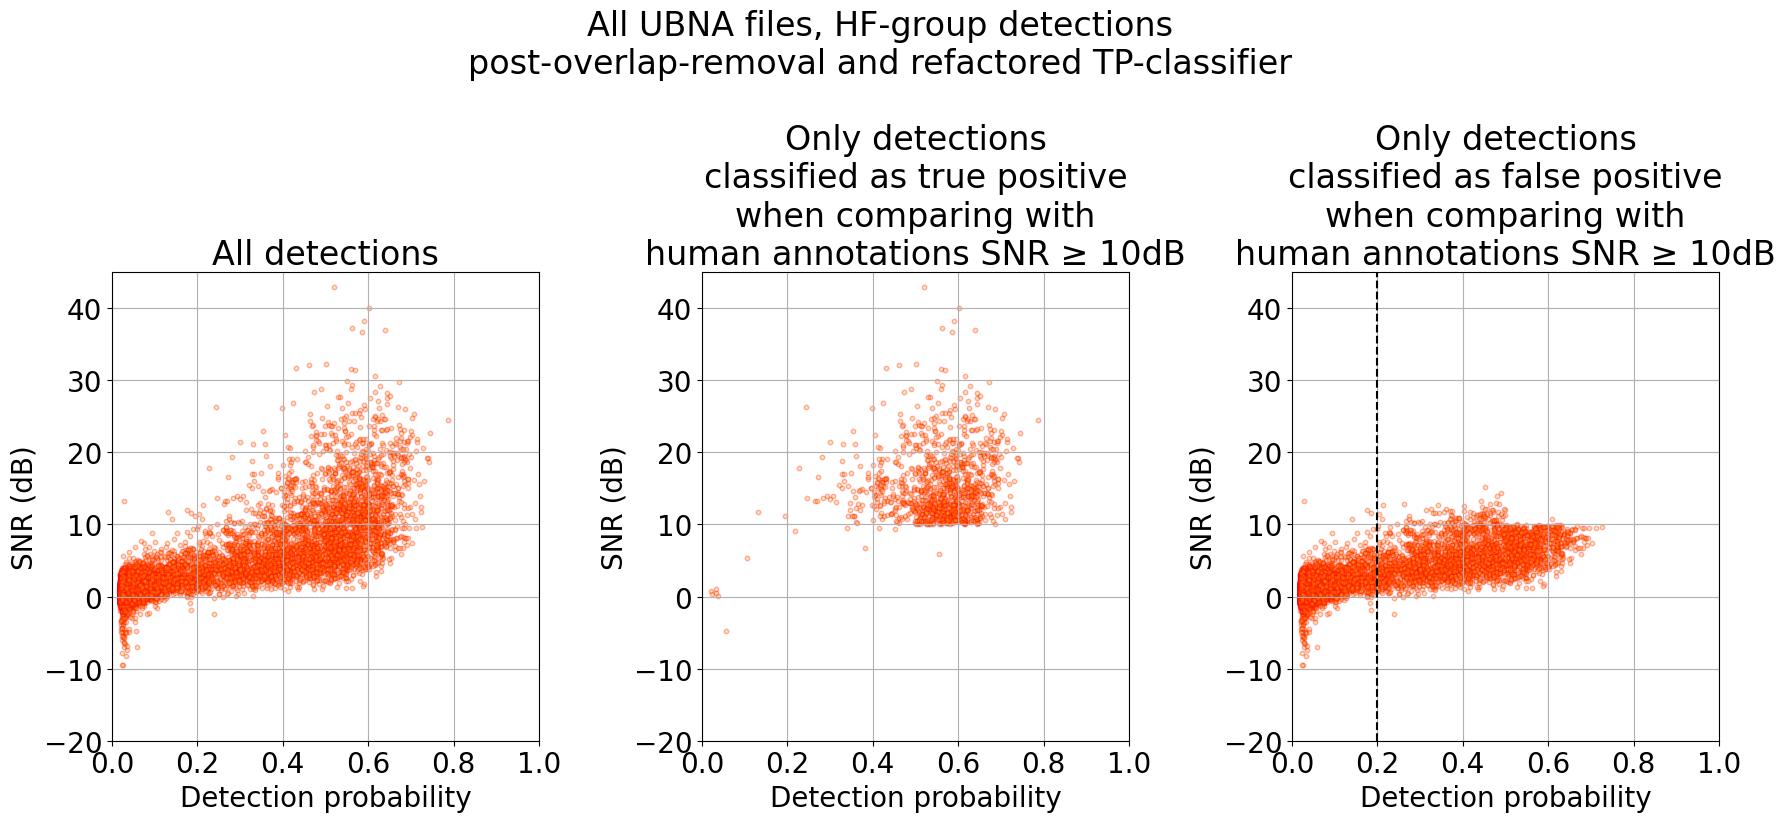

In [13]:
for snrthresh in snr_thresholds:    
    all_files_batdetct2_df = pd.DataFrame()
    lf_files_batdetct2_df = pd.DataFrame()
    hf_files_batdetct2_df = pd.DataFrame()

    lf_files_true_positives_batdetct2_df = pd.DataFrame()
    hf_files_true_positives_batdetct2_df = pd.DataFrame()

    lf_files_false_positives_batdetct2_df = pd.DataFrame()
    hf_files_false_positives_batdetct2_df = pd.DataFrame()

    lf_human_bd2_overlaps = pd.DataFrame()
    hf_human_bd2_overlaps = pd.DataFrame()

    lf_human_true_positives_with_bd2overlap = 0
    hf_human_true_positives_with_bd2overlap = 0

    lf_bd2_false_positives_with_humanoverlap = 0
    lf_bd2_false_positives_total = 0
    hf_bd2_false_positives_with_humanoverlap = 0
    hf_bd2_false_positives_total = 0

    for file_key in file_keys:
        print(f'Computing measures for file {file_key}.WAV')
        wav_filename = file_key
        site = FILE_SITES[file_key]
        plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
        raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

        snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
        bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
        bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
        bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                    'End Time (s)':'end_time',
                                    'Low Freq (Hz)':'low_freq',
                                    'High Freq (Hz)':'high_freq',
                                    'Delta Time (s)':'delta_time_s',
                                    'Manually-Verified Phonic Group':'freq_group',
                                    'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
        bd2_human_df_file.sort_values('start_time', inplace=True)
        bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=snrthresh].copy()

        lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
        hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
        print(f'Human annotations: {len(bd2_human_df_file)} total, {len(lf_bd2_human_df_file)} LF, {len(hf_bd2_human_df_file)} HF')

        args = dict()
        args['chunk_size'] = 2
        args['detection_threshold'] = 0.00
        ones = int(args['detection_threshold'])
        decimals = int(int(100*(args['detection_threshold'])) % 100)
        threshold_tag = f"threshold{ones}p{decimals:02}"
        save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
        filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
        bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
        bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
        lf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF'].reset_index(drop=True).copy()
        hf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF'].reset_index(drop=True).copy()
        print(f'BD2 detections: {len(bd2_file_all_dets)} total, {len(lf_bd2_file_all_dets)} LF, {len(hf_bd2_file_all_dets)} HF')

        all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, bd2_file_all_dets])
        lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_bd2_file_all_dets])
        hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_bd2_file_all_dets])

        lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_bd2_file_all_dets)
        hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_bd2_file_all_dets)

        lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
        lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
        lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
        lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
        print(f'LF measures: \n{len(lf_bd2_true_positives)} BD2 true positives\n{len(lf_bd2_false_negatives)} BD2 false negatives\n{len(lf_bd2_false_positives)} BD2 false positives\n{len(lf_human_true_positives)} human true positives')
        lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
        lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])

        hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
        hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
        hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
        hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
        print(f'HF measures: \n{len(hf_bd2_true_positives)} BD2 true positives\n{len(hf_bd2_false_negatives)} BD2 false negatives\n{len(hf_bd2_false_positives)} BD2 false positives\n{len(hf_human_true_positives)} human true positives')
        hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
        hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])

        num_trues_each_col = lf_association_matrix.sum(axis=0)
        lf_human_dets_with_overlap_bd2_dets = lf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
        lf_human_bd2_overlaps = pd.concat([lf_human_bd2_overlaps, lf_human_dets_with_overlap_bd2_dets])
        print(f'{len(lf_human_dets_with_overlap_bd2_dets)} LF human annotations each with 2 corresponding true positives')
        lf_human_true_positives_with_bd2overlap+=len(lf_human_dets_with_overlap_bd2_dets)

        num_trues_each_col = hf_association_matrix.sum(axis=0)
        hf_human_dets_with_overlap_bd2_dets = hf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
        hf_human_bd2_overlaps = pd.concat([hf_human_bd2_overlaps, hf_human_dets_with_overlap_bd2_dets])
        print(f'{len(hf_human_dets_with_overlap_bd2_dets)} HF human annotations each with 2 corresponding true positives')
        hf_human_true_positives_with_bd2overlap+=len(hf_human_dets_with_overlap_bd2_dets)

        suspect_lf_bd2_false_positives = lf_bd2_false_positives[lf_bd2_false_positives['det_prob']>0.2]
        selections = suspect_lf_bd2_false_positives.reset_index(drop=True).copy()
        overlap_count = 0
        overlap_determination_thresh = 32
        for ind, selection_row in selections.iterrows():
            input_file = Path(selection_row['input_file'])
            raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

            start = selection_row['start_time']-0.05
            duration = (selection_row['end_time']-selection_row['start_time'])+0.1
            plot_humandets = lf_bd2_human_df_file[(lf_bd2_human_df_file['start_time']>=start)&(lf_bd2_human_df_file['end_time']<=(start+duration))]
            shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
            if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
                overlap_count+=1
        print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) LF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')
        lf_bd2_false_positives_with_humanoverlap+=overlap_count
        lf_bd2_false_positives_total+=len(selections)

        suspect_hf_bd2_false_positives = hf_bd2_false_positives[hf_bd2_false_positives['det_prob']>0.2]
        selections = suspect_hf_bd2_false_positives.reset_index(drop=True).copy()
        overlap_count = 0
        overlap_determination_thresh = 20
        for ind, selection_row in selections.iterrows():
            input_file = Path(selection_row['input_file'])
            raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

            start = selection_row['start_time']-0.05
            duration = (selection_row['end_time']-selection_row['start_time'])+0.1
            plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
            shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
            if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
                overlap_count+=1
        print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) HF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')
        hf_bd2_false_positives_with_humanoverlap+=overlap_count
        hf_bd2_false_positives_total+=len(selections)

    print(f'TOTAL: {lf_human_true_positives_with_bd2overlap} LF human annotations each with 2 corresponding true positives')
    print(f'TOTAL: {lf_bd2_false_positives_with_humanoverlap}/{lf_bd2_false_positives_total} ({round(lf_bd2_false_positives_with_humanoverlap/lf_bd2_false_positives_total, 3)}) LF false positives with det_prob>0.2 were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < 32ms')

    print(f'TOTAL: {hf_human_true_positives_with_bd2overlap} HF human annotations each with 2 corresponding true positives')
    print(f'TOTAL: {hf_bd2_false_positives_with_humanoverlap}/{hf_bd2_false_positives_total} ({round(hf_bd2_false_positives_with_humanoverlap/hf_bd2_false_positives_total, 3)}) HF false positives with det_prob>0.2 were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < 20ms')

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,8.5))
    plt.rcParams.update({'font.size':20})

    fig.suptitle(f'All UBNA files, LF-group detections\npost-overlap-removal and refactored TP-classifier')

    ax = ax1
    ax.set_title(f'All detections')
    ax.scatter(lf_files_batdetct2_df['det_prob'].values, lf_files_batdetct2_df['SNR'].values,
                alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)

    ax = ax2
    ax.set_title(f'Only detections\nclassified as true positive\nwhen comparing with\nhuman annotations SNR ≥ {snrthresh}dB')
    ax.scatter(lf_files_true_positives_batdetct2_df['det_prob'].values, lf_files_true_positives_batdetct2_df['SNR'].values,
                alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)

    ax = ax3
    ax.set_title(f'Only detections\nclassified as false positive\nwhen comparing with\nhuman annotations SNR ≥ {snrthresh}dB')
    ax.scatter(lf_files_false_positives_batdetct2_df['det_prob'].values, lf_files_false_positives_batdetct2_df['SNR'].values,
                alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
    ax.axvline(x=0.2, linestyle='dashed', color='k')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)


    fig.tight_layout()
    plt.show()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,8.5))
    plt.rcParams.update({'font.size':20})

    fig.suptitle(f'All UBNA files, HF-group detections\npost-overlap-removal and refactored TP-classifier')

    ax = ax1
    ax.set_title(f'All detections')
    ax.scatter(hf_files_batdetct2_df['det_prob'].values, hf_files_batdetct2_df['SNR'].values,
                alpha=0.3, s=10, facecolor='orange', edgecolor='red')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)

    ax = ax2
    ax.set_title(f'Only detections\nclassified as true positive\nwhen comparing with\nhuman annotations SNR ≥ {snrthresh}dB')
    ax.scatter(hf_files_true_positives_batdetct2_df['det_prob'].values, hf_files_true_positives_batdetct2_df['SNR'].values,
                alpha=0.3, s=10, facecolor='orange', edgecolor='red')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)

    ax = ax3
    ax.set_title(f'Only detections\nclassified as false positive\nwhen comparing with\nhuman annotations SNR ≥ {snrthresh}dB')
    ax.scatter(hf_files_false_positives_batdetct2_df['det_prob'].values, hf_files_false_positives_batdetct2_df['SNR'].values,
                alpha=0.3, s=10, facecolor='orange', edgecolor='red')
    ax.axvline(x=0.2, linestyle='dashed', color='k')
    ax.grid(which='both')
    ax.set_xlabel('Detection probability')
    ax.set_ylabel('SNR (dB)')
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-20, 45.0)


    fig.tight_layout()
    plt.show()